In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from IPython.display import display
from clean import *
from sklearn.metrics.pairwise import cosine_similarity
from statsmodels.stats.proportion import proportions_ztest
import seaborn as sns
from pecarn_models import *
import sklearn as skl
from sklearn.model_selection import GridSearchCV
import graphviz
from pathlib import Path


random.seed(42)

dir = Path.cwd().parent

data = pd.read_csv(dir / "data" / "TBI PUD 10-08-2013.csv")

## Data Exploration/Data Cleaning

Sum over 2: 32495, Sum under 2: 10904


AgeTwoPlus
2 and over    32495
Under 2       10904
Name: count, dtype: int64

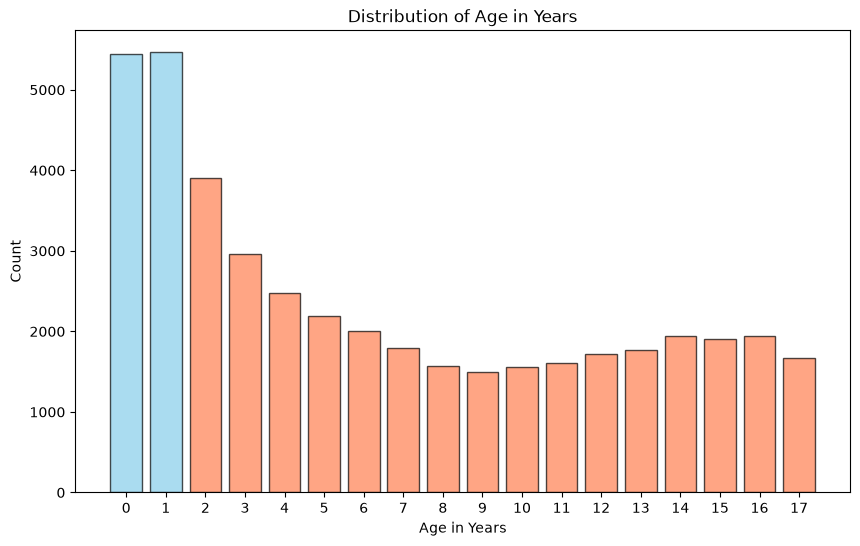

In [2]:
# Figure displaying the distribution of Age in Years
# Verifies that the number of patients in binary variables 'AgeTwoPlus' and 'AgeinYears' are consistent with each other.

fig = plt.figure(figsize = (10, 6))

Age = data['AgeinYears']

labels = list(range(0, 18))

binsmap = (
    Age
    .value_counts()
    .reindex(labels, fill_value=0)
)

sum_under_2 = binsmap[binsmap.index < 2].sum()
sum_over_2 = binsmap[binsmap.index >= 2].sum()

print(f"Sum over 2: {sum_over_2}, Sum under 2: {sum_under_2}")

under_and_over_2 = data['AgeTwoPlus'].replace({1: 'Under 2', 2: '2 and over'}).value_counts()

display(under_and_over_2)

colors = ['skyblue' if age < 2 else 'coral' for age in binsmap.index]

plt.bar(binsmap.index, binsmap.values, edgecolor='black', facecolor=colors, alpha=0.7)
plt.xlabel('Age in Years')
plt.ylabel('Count')
plt.title('Distribution of Age in Years')
plt.xticks(range(0, 18))
plt.savefig(dir / 'figs' / 'age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()



A few things to note: firstly, it was verified that the number in each binary variable 'AgeTwoPlus' and 'AgeinYears' are consistent with each other. With this in mind, for easy of cleaning, we will then only include 'AgeTwoPlus' in the analysis. Additionally, when we look at the figure, we see that within each group (<2 and >=2), there are comparable number of patients at each age group, just confirming (especiialy with considering the size of the dataset) that we have a good distribution of patients across age groups.

Percentage of patients with GCS < 3 under 2 years old: 0.00%
Percentage of patients with GCS < 3 2 years and older: 0.00%
Percentage of patients with GCS > 15 under 2 years old: 0.00%
Percentage of patients with GCS > 15 2 years and older: 0.00%


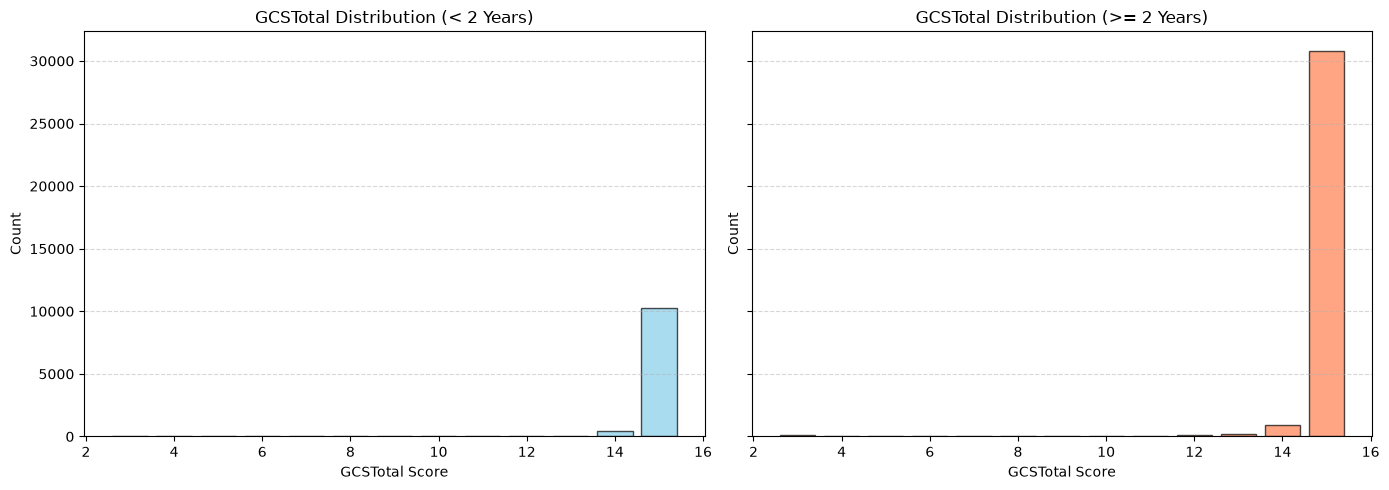

In [3]:
# Displays the distribution of GCSTotal for patients under 2 years old and those 2 years and older, along with the percentage of patients with GCS < 3 and GCS > 15 in each age group.

under_2 = data[data['AgeinYears'] < 2]
over_2 = data[data['AgeinYears'] >= 2]

gcs_under_2 = under_2['GCSTotal'].value_counts().sort_index()
gcs_over_2 = over_2['GCSTotal'].value_counts().sort_index()

number_less_3_under_2 = (gcs_under_2[gcs_under_2.index < 3].sum() / gcs_under_2.sum()) * 100
number_less_3_over_2 = (gcs_over_2[gcs_over_2.index < 3].sum() / gcs_over_2.sum()) * 100

print((f"Percentage of patients with GCS < 3 under 2 years old: {number_less_3_under_2:.2f}%"))
print((f"Percentage of patients with GCS < 3 2 years and older: {number_less_3_over_2:.2f}%"))

number_over_15_under_2 = (gcs_under_2[gcs_under_2.index > 15].sum() / gcs_under_2.sum()) * 100
number_over_15_over_2 = (gcs_over_2[gcs_over_2.index > 15].sum() / gcs_over_2.sum()) * 100

print((f"Percentage of patients with GCS > 15 under 2 years old: {number_over_15_under_2:.2f}%"))
print((f"Percentage of patients with GCS > 15 2 years and older: {number_over_15_over_2:.2f}%"))


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot 1: Under 2 Years
axes[0].bar(gcs_under_2.index, gcs_under_2.values, edgecolor='black', color='skyblue', alpha=0.7)
axes[0].set_title('GCSTotal Distribution (< 2 Years)')
axes[0].set_xlabel('GCSTotal Score')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 2: 2 Years and Older
axes[1].bar(gcs_over_2.index, gcs_over_2.values, edgecolor='black', color='coral', alpha=0.7)
axes[1].set_title('GCSTotal Distribution (>= 2 Years)')
axes[1].set_xlabel('GCSTotal Score')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(dir / 'figs' / 'gcs_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


The above figure confirms that the majority of the patients in the data set do in fact have GCS 14 or 15, with a large proportion with GCS score of 15. This connects well to the defintion of AMS, as one fo the criteria for AMS is a GCS score of less than 15. A reality check is also considered: we know that GCS score are between 3 and 15, and it is confirmed that no values of GCS are recorded <3 or >15. Thus, to filtering our patients to have GCS = {14, 15} in the next step, we just need to filter GCSTotal >= 14.

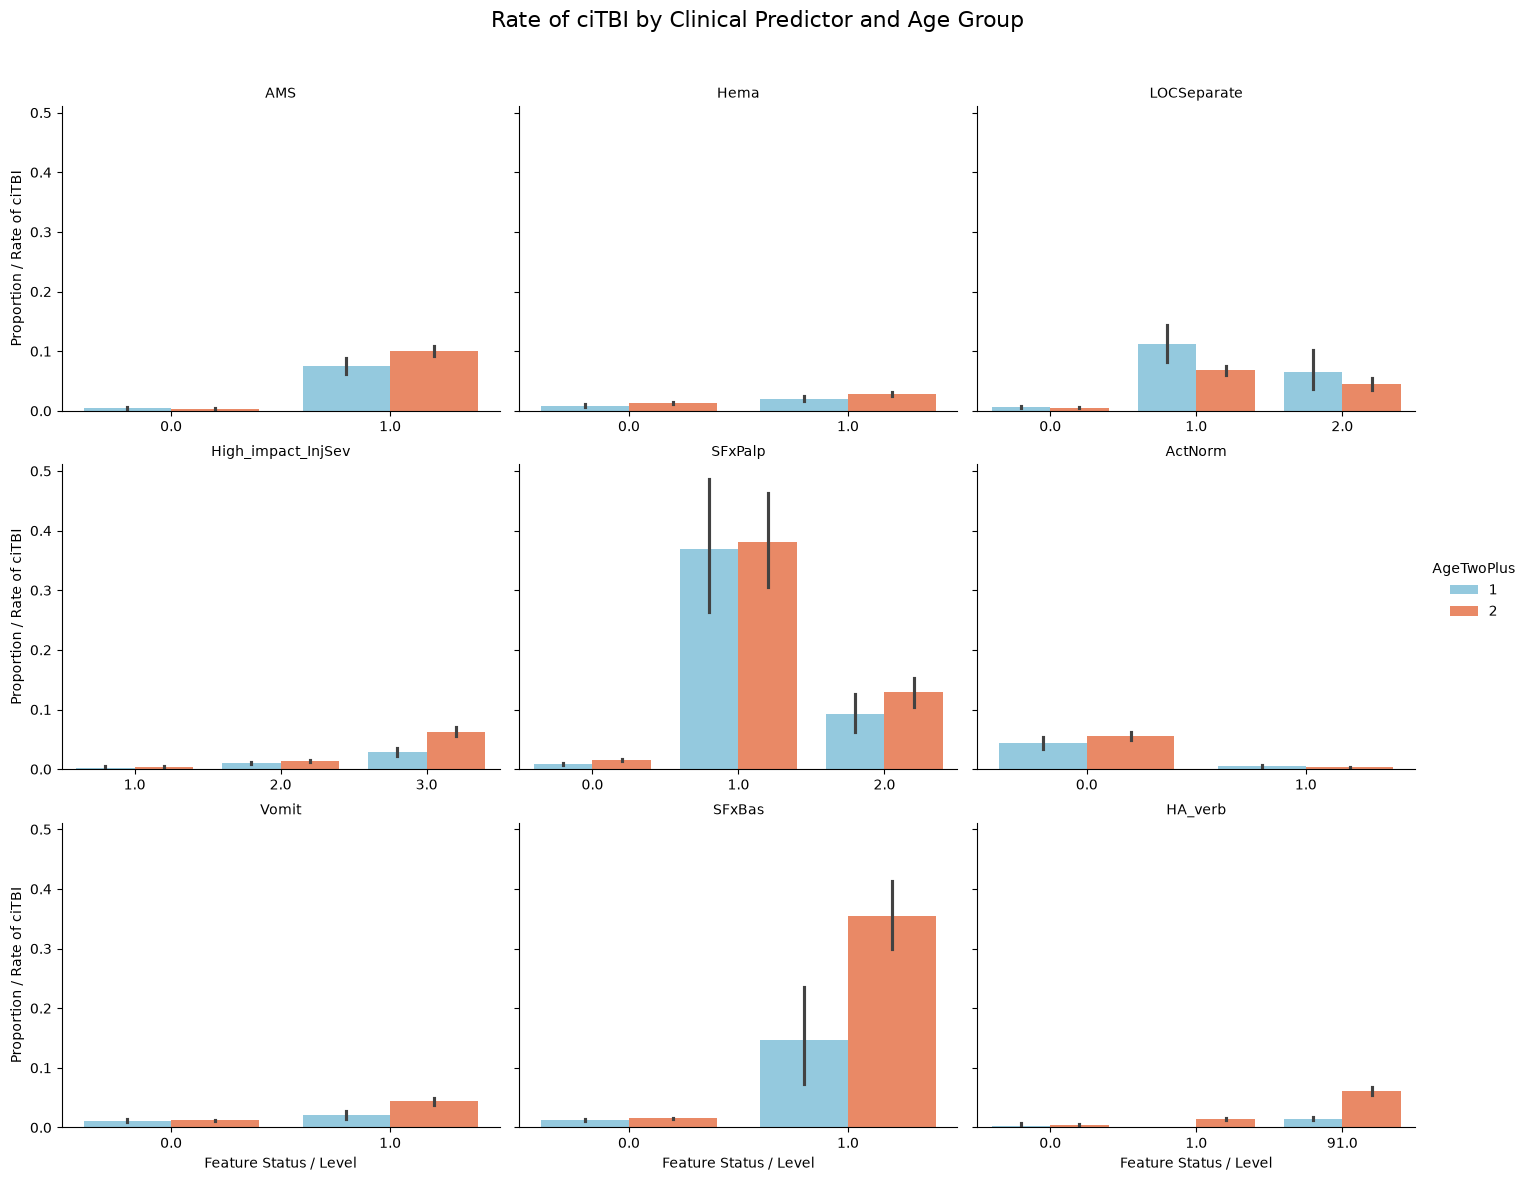

In [4]:
# Displays the distribution of clinical features of interest and their relationship with the outcome variable 'PosIntFinal' (ciTBI) for patients under 2 years old and those 2 years and older.

features_of_interest = [
    'AMS', 'Hema', 'LOCSeparate', 'High_impact_InjSev', 
    'SFxPalp', 'ActNorm', 'Vomit', 'SFxBas', 'HA_verb']

valid_features = [f for f in features_of_interest if f in data.columns]

df_long = pd.melt(
    data, 
    id_vars=['AgeTwoPlus', 'PosIntFinal'], 
    value_vars=valid_features,
    var_name='Clinical_Feature', 
    value_name='Feature_Value'
)

# Subplot layout
g = sns.catplot(
    data=df_long,
    x='Feature_Value',
    y='PosIntFinal',
    hue='AgeTwoPlus',
    col='Clinical_Feature',
    col_wrap=3,
    kind='bar',
    errorbar=('ci', 95),
    height=4,
    aspect=1.2,
    palette=['skyblue', 'coral'],
    sharex=False,
    sharey=True
)

g.set_axis_labels("Feature Status / Level", "Proportion / Rate of ciTBI")
g.set_titles(col_template="{col_name}")

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Rate of ciTBI by Clinical Predictor and Age Group', fontsize=16)

plt.savefig(dir / 'figs' / 'clinical_features.png', dpi=300, bbox_inches='tight')
plt.show()

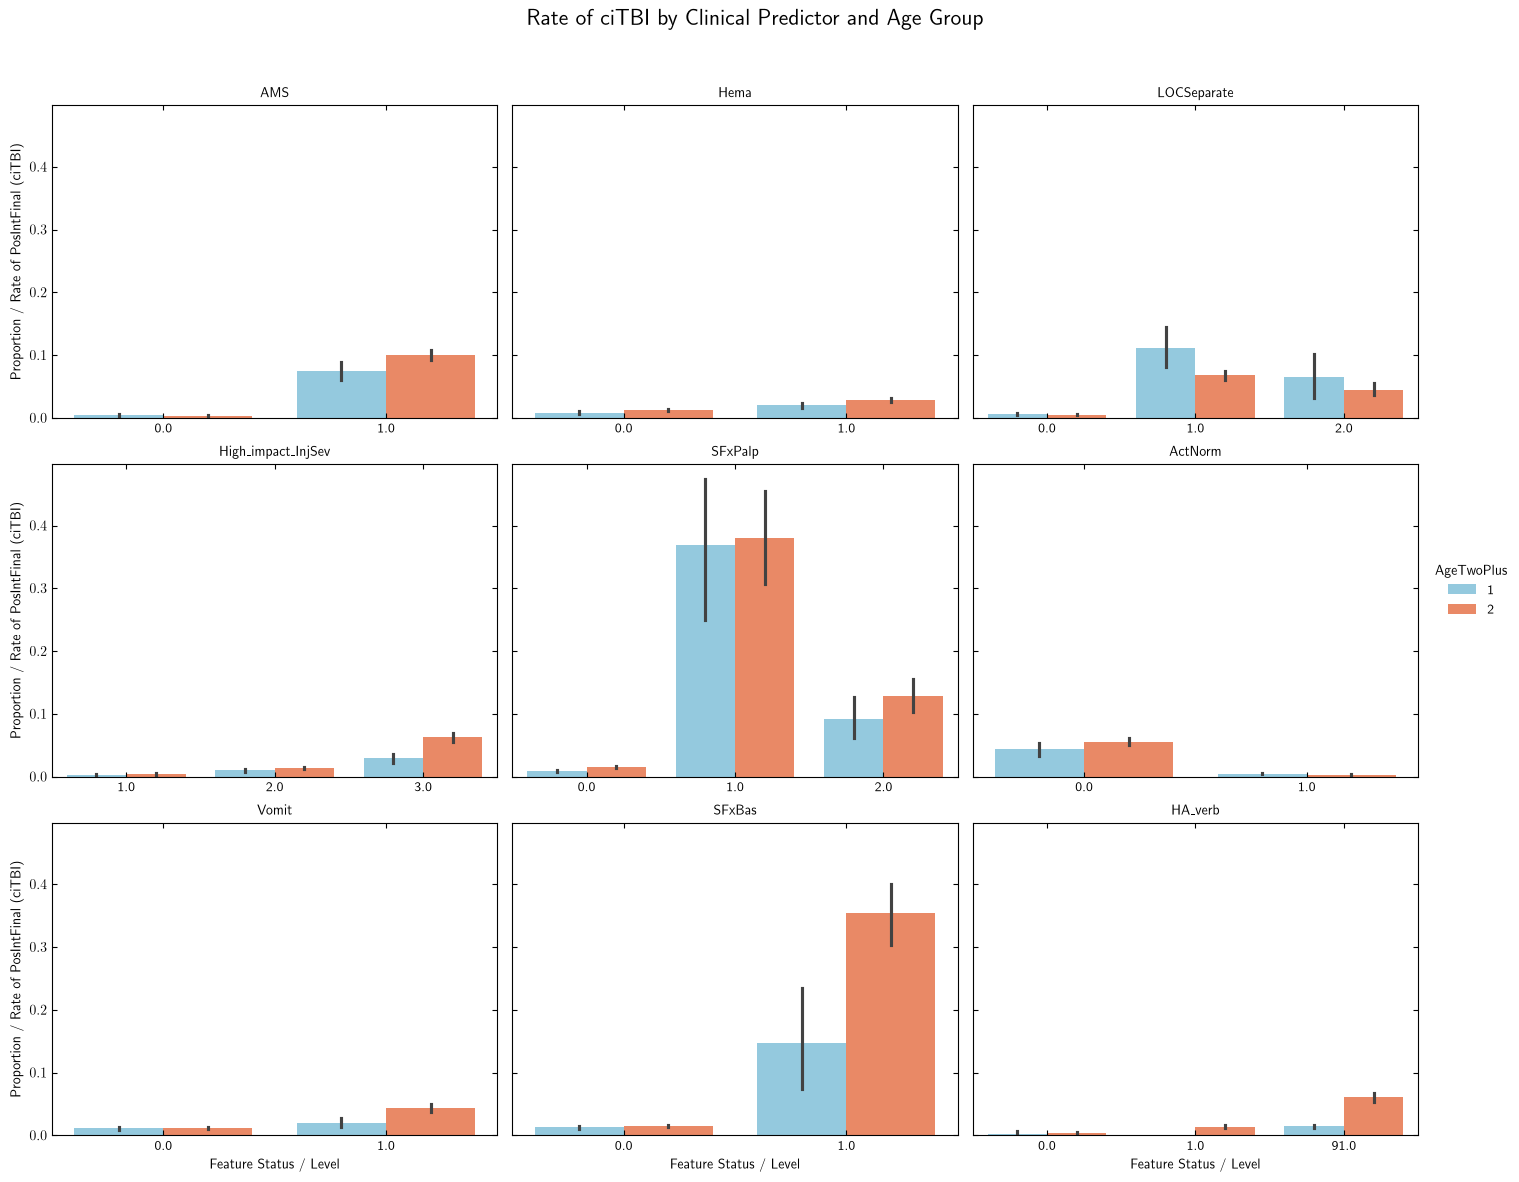

In [5]:
# Report ready distribution of clinical features of interest and their relationship with the outcome variable 'PosIntFinal' (ciTBI) for patients under 2 years old and those 2 years and older.

plt.rc('text', usetex=True)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

features_of_interest = [
    'AMS', 'Hema', 'LOCSeparate', 'High_impact_InjSev', 
    'SFxPalp', 'ActNorm', 'Vomit', 'SFxBas', 'HA_verb'
]

valid_features = [f for f in features_of_interest if f in data.columns]

df_long = pd.melt(
    data, 
    id_vars=['AgeTwoPlus', 'PosIntFinal'], 
    value_vars=valid_features,
    var_name='Clinical_Feature', 
    value_name='Feature_Value'
)

# Subplot layout
g = sns.catplot(
    data=df_long,
    x='Feature_Value',
    y='PosIntFinal',
    hue='AgeTwoPlus',
    col='Clinical_Feature',
    col_wrap=3,
    kind='bar',
    errorbar=('ci', 95),
    height=4,
    aspect=1.2,
    palette=['skyblue', 'coral'],
    sharex=False,
    sharey=True
)

g.set_axis_labels("Feature Status / Level", "Proportion / Rate of PosIntFinal (ciTBI)")
g.set_titles(col_template="{col_name}")

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Rate of ciTBI by Clinical Predictor and Age Group', fontsize=16)

for ax in g.axes.flat:
    ax.spines[['top', 'right']].set_visible(True)

plt.savefig(dir / 'figs' / 'clinical_features_report.png', dpi=300, bbox_inches='tight')
plt.show()

For the clinical variables defined in Kuppermann (2013), the above graph shows their distribution and the relationship with ciTBI for the two age groups (<2 and >=2). The error bars represent the 95% confidence intervals for the proportion of patients with ciTBI within each feature level and age group. Some brief comments: all variables have a higher proportion -- in both age groups -- of patients with ciTBI when the feature is present (or abnormal) compared to when it is absent (or normal). This suggests that these clinical features are associated with an increased risk of ciTBI. The differences in proportions between the two age groups may also indicate that age modifies the relationship between these clinical features and the risk of ciTBI. Note that the feature being present means the variable is marked as '1' except for the cases of 'High_impact_InjSev' and 'ActNorm', where severity is an ordinal variable, the larger the value, the more severe the injury (thus high severity has a higher risk of ciTBI) and act norm of 0 is indicative that the patient is not acting normally, which is associated with a higher risk of ciTBI. Note that if a patient's palpable skull fracture exam is unclear, there is also a higher risk of ciTBI compared to the absence of the fracture. Similar behavior is seen when LOC is suspected. 

In [6]:
print(data['HA_verb'][data['AgeTwoPlus'] == 1].value_counts())

HA_verb
91.0    9790
0.0     1002
1.0       25
Name: count, dtype: int64


Below, I am filtering the data to look at only patients with GCS = {14, 15}, to match Kuppermann's exclusion criteria, as to only look at patients who are at low-risk of ciTBI. I am also filtering out the patients with missing primary outcome to match Kuppermann's exclusion criteria. Note that the data is filtered so that patients with a GCSTotal score >= 14 or patients with a GCS sum of the components (Eye, Verbal, and Motor) >= 14, to ensure consistency for a later data cleaning step.

In [7]:
# Filtering GCS scores
data_gcs_filtered = data[(data['GCSTotal'] >= 14) | (data['GCSEye'] + data['GCSVerbal'] + data['GCSMotor'] >= 14)]

# Filtering missing primary outcome -- we don't want to keep and analyze patients with missing outcome data.
data_primary_outcome_filtered = data_gcs_filtered.dropna(subset=['PosIntFinal'])

print(data_primary_outcome_filtered.shape)
print(data_primary_outcome_filtered['PosIntFinal'].value_counts())

(42412, 125)
PosIntFinal
0.0    42036
1.0      376
Name: count, dtype: int64


Time to split test/train so that there is no data leakage when doing exploratory data analysis that influences cleaning procedures. I initially wanted to take the same splits as given in the paper. There are two things to note here when doing test/train split: 1. Since this data includes 25 hospitals, a very beneifical way would be to split by hospital, keeping hospital data together in either the testing/training sets, or 2. There was data specifically retrieved to be in the test set, data collected after the orginal data was collected, so naturally that would become the test set (essentially functioning as the future data we are wanting to validate on). Since the paper does the latter, I will split the data in the same way. It is also of note that inter-rater variability could be an issue in this data set, i.e., different technicians might record different answers for the same patient. Kuppermann's paper mentions, at each site, 4% of patients had two assessments to analyze the inter-rater variability, but this data is not available for us to use as a sanity-check.

In [8]:
# Split the data into subgroups based on AgeTwoPlus.

data_under_2 = data_primary_outcome_filtered[data_primary_outcome_filtered['AgeTwoPlus'] == 1]
data_over_2 = data_primary_outcome_filtered[data_primary_outcome_filtered['AgeTwoPlus'] == 2]

train_data_under_2 = data_under_2.iloc[:8502, :]
train_data_over_2 = data_over_2.iloc[:25283, :]

test_data_under_2 = data_under_2.iloc[8502:, :]
test_data_over_2 = data_over_2.iloc[25283:, :]

print(train_data_under_2.shape)
print(train_data_over_2.shape)
print(test_data_under_2.shape)
print(test_data_over_2.shape)

(8502, 125)
(25283, 125)
(2216, 125)
(6411, 125)


Now that the data has been split into the same way Kuppermann did (not actually as noted later -- it was split with assumption that the data was order by time collected, the idea with this assumption was to end up with the same splits by taking the numbers within the test/train from the paper), since we were not given a date for the data collection (which is necessary to know the data that comes from March - September, 2006, the validation set), we dont actually know if these partitions are equal. I am making the assumption that the data should be ordered by date, so the first ~80% of each group should be placed in the train, and the rest in the test. In order to test this hypothesis, I am going to generate some summary statistics of both training sets to see if they are identical to that of Kuppermann's derivation set. Note this is not fool-proof, this does not guarentee they are identical sets, but I hope to establish enough confidence to proceed with the data that I currently have and build the training and testing set as close to that to mimic current and future data. 

In [9]:
# Check whether proportion of splits is identical to the original dataset

categorical_features = ['High_impact_InjSev', 'LOCSeparate', 'LocLen', 'Vomit', 'VomitNbr', 'ActNorm', 'GCSTotal', 'AMS', 'SFxBas', 'SFxPalp', 'Hema', 'HemaLoc', 'PosIntFinal', 'Neurosurgery', 'PosCT']

counts_under_2 = train_data_under_2[categorical_features].apply(lambda x: x.value_counts(normalize=False))

counts_over_2 = train_data_over_2[categorical_features].apply(lambda x: x.value_counts(normalize=False))

display(counts_under_2)
display(counts_over_2)


,High_impact_InjSev,LOCSeparate,LocLen,Vomit,VomitNbr,ActNorm,GCSTotal,AMS,SFxBas,SFxPalp,Hema,HemaLoc,PosIntFinal,Neurosurgery,PosCT
0.0,NaN,7772.0,NaN,7212.0,NaN,1143.0,NaN,7502.0,8357.0,8202.0,4724.0,NaN,8421.0,8486.0,2420.0
1.0,1247.0,273.0,64.0,1230.0,520.0,7028.0,NaN,940.0,44.0,46.0,3726.0,2347.0,81.0,16.0,230.0
2.0,5311.0,150.0,167.0,NaN,253.0,NaN,NaN,NaN,NaN,237.0,NaN,484.0,NaN,NaN,NaN
3.0,1860.0,NaN,80.0,NaN,401.0,NaN,NaN,NaN,NaN,NaN,NaN,850.0,NaN,NaN,NaN
4.0,NaN,NaN,46.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14.0,NaN,NaN,NaN,NaN,NaN,NaN,351.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15.0,NaN,NaN,NaN,NaN,NaN,NaN,8151.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92.0,NaN,NaN,8079.0,NaN,7272.0,NaN,NaN,NaN,NaN,NaN,NaN,4776.0,NaN,NaN,5852.0


,High_impact_InjSev,LOCSeparate,LocLen,Vomit,VomitNbr,ActNorm,GCSTotal,AMS,SFxBas,SFxPalp,Hema,HemaLoc,PosIntFinal,Neurosurgery,PosCT
0.0,NaN,19652.0,NaN,21917.0,NaN,3799.0,NaN,21668.0,24887.0,24688.0,15524.0,NaN,25066.0,25256.0,8910.0
1.0,4392.0,3224.0,680.0,3186.0,1130.0,19400.0,NaN,3436.0,175.0,73.0,9568.0,4590.0,217.0,27.0,390.0
2.0,17574.0,1365.0,1282.0,NaN,641.0,NaN,NaN,NaN,NaN,458.0,NaN,2298.0,NaN,NaN,NaN
3.0,3160.0,NaN,753.0,NaN,1268.0,NaN,NaN,NaN,NaN,NaN,NaN,2556.0,NaN,NaN,NaN
4.0,NaN,NaN,130.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14.0,NaN,NaN,NaN,NaN,NaN,NaN,706.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15.0,NaN,NaN,NaN,NaN,NaN,NaN,24577.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92.0,NaN,NaN,20694.0,NaN,22097.0,NaN,NaN,NaN,NaN,NaN,NaN,15715.0,NaN,NaN,15983.0


It is clear after looking at the proportions that the data in the excel file is not ordered by date, thus that split assumption fails. To ensure a proper split, and the lack of data to prepare the best splits, I will randomly select 80% for each subgroup (<2 and >=2), to match the approx. 80/20 split from the paper.

In [10]:
# Split the data into training and testing sets use 80/20 split

train_under_2 = data_under_2.sample(frac=0.8, random_state=42)
train_over_2 = data_over_2.sample(frac=0.8, random_state=42)

test_under_2 = data_under_2.drop(train_under_2.index)
test_over_2 = data_over_2.drop(train_over_2.index)

print(train_under_2.shape)
print(train_over_2.shape)
print(test_under_2.shape)
print(test_over_2.shape)

(8574, 125)
(25355, 125)
(2144, 125)
(6339, 125)


In [11]:
categorical_features = ['High_impact_InjSev', 'LOCSeparate', 'LocLen', 'Vomit', 'VomitNbr', 'ActNorm', 'GCSTotal', 'AMS', 'SFxBas', 'SFxPalp', 'Hema', 'HemaLoc', 'PosIntFinal', 'Neurosurgery', 'PosCT']

proportions_under_2 = train_data_under_2[categorical_features].apply(lambda x: x.value_counts(normalize=True)) * 100
proportions_over_2 = train_data_over_2[categorical_features].apply(lambda x: x.value_counts(normalize=True)) * 100

display(proportions_under_2)
display(proportions_over_2)

,High_impact_InjSev,LOCSeparate,LocLen,Vomit,VomitNbr,ActNorm,GCSTotal,AMS,SFxBas,SFxPalp,Hema,HemaLoc,PosIntFinal,Neurosurgery,PosCT
0.0,NaN,94.838316,NaN,85.429993,NaN,13.988496,NaN,88.865198,99.476253,96.664702,55.905325,NaN,99.047283,99.811809,28.463891
1.0,14.813495,3.331300,0.758653,14.570007,6.156761,86.011504,NaN,11.134802,0.523747,0.542133,44.094675,27.752158,0.952717,0.188191,2.705246
2.0,63.090995,1.830384,1.979611,NaN,2.995501,NaN,NaN,NaN,NaN,2.793164,NaN,5.723070,NaN,NaN,NaN
3.0,22.095510,NaN,0.948317,NaN,4.747810,NaN,NaN,NaN,NaN,NaN,NaN,10.050845,NaN,NaN,NaN
4.0,NaN,NaN,0.545282,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14.0,NaN,NaN,NaN,NaN,NaN,NaN,4.12844,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15.0,NaN,NaN,NaN,NaN,NaN,NaN,95.87156,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92.0,NaN,NaN,95.768137,NaN,86.099929,NaN,NaN,NaN,NaN,NaN,NaN,56.473927,NaN,NaN,68.830863


,High_impact_InjSev,LOCSeparate,LocLen,Vomit,VomitNbr,ActNorm,GCSTotal,AMS,SFxBas,SFxPalp,Hema,HemaLoc,PosIntFinal,Neurosurgery,PosCT
0.0,NaN,81.069263,NaN,87.30829,NaN,16.375706,NaN,86.312938,99.301732,97.894445,61.868325,NaN,99.141716,99.893209,35.241071
1.0,17.479901,13.299781,2.888823,12.69171,4.495544,83.624294,NaN,13.687062,0.698268,0.289464,38.131675,18.243968,0.858284,0.106791,1.542538
2.0,69.943485,5.630956,5.446281,NaN,2.550127,NaN,NaN,NaN,NaN,1.816091,NaN,9.133908,NaN,NaN,NaN
3.0,12.576614,NaN,3.198946,NaN,5.044558,NaN,NaN,NaN,NaN,NaN,NaN,10.159386,NaN,NaN,NaN
4.0,NaN,NaN,0.552275,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14.0,NaN,NaN,NaN,NaN,NaN,NaN,2.79239,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15.0,NaN,NaN,NaN,NaN,NaN,NaN,97.20761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92.0,NaN,NaN,87.913675,NaN,87.909771,NaN,NaN,NaN,NaN,NaN,NaN,62.462737,NaN,NaN,63.216390


Since the proportions of splits are very similar to the original dataset, we can conclude that the splits are representative of the original dataset. Let's now proceed with cleaning data. I will start with the orginal 6 predictors Kuppermann used in the CDR, as I want to at minimum validate the CDR or building upon them. Let's start by cleaning: (<2) altered mental status, scalp haematoma, loss of consciousness, mechanism of injury, palpable (or unclear) skull fracture, acting normal per parent, and (>=2) AMS, loss of consciousness, history of vomiting, mechaism of injury, clinical signs of basilar skull fracture, severe headache, and variables associated to these predictors (with the goal of showing: do my specific judgment calls change the CDR, and if for example, I add more variables, do we get better rules, i.e. we know that gender plays an effect on biological makeup--should the rules be different for female/male?). 

I will not include any indicator variables, as they are under the condition of getting a CT, I want to look at the data prior to information about whether a patient had a CT scan or not.

The following is a list of all variables I will keep for down-stream cleaning/analysis:

Injury mechanism, injury severity, history and duration of loss of consciousness, acting normal, headache at eval, head severirty and start, vomiting and its relavent information, GCS score and all subcategories, altered mental status and all subcategories, palpable skull fracture and depression information, signs of basillar skull fracture and all subcategories, hematoma and all subcategories, neurodeficiet and all subcategories, gender, age, and the main response: ciTBI and subcategories.

In [12]:
reduced_train_data_under_2 = train_data_under_2[['AgeTwoPlus', 'InjuryMech', 'High_impact_InjSev', 'LOCSeparate', 'LocLen', 'HA_verb', 'HASeverity', 'HAStart', 'Vomit', 'VomitNbr', 'VomitStart', 'VomitLast', 'GCSEye', 'GCSVerbal', 'GCSMotor', 'GCSTotal', 'AMS', 'AMSAgitated', 'AMSSleep', 'AMSSlow', 'AMSRepeat', 'AMSOth', 'SFxPalp', 'SFxPalpDepress', 'SFxBas', 'SFxBasHem', 'SFxBasOto', 'SFxBasPer', 'SFxBasRet', 'SFxBasRhi', 'Hema', 'HemaLoc', 'HemaSize', 'NeuroD', 'NeuroDMotor', 'NeuroDSensory', 'NeuroDCranial', 'NeuroDReflex', 'NeuroDOth', 'Gender', 'ActNorm', 'DeathTBI', 'HospHead', 'HospHeadPosCT', 'Intub24Head', 'Neurosurgery', 'PosIntFinal', 'Race', 'CTDone']]
reduced_train_data_over_2 = train_data_over_2[['AgeTwoPlus', 'InjuryMech', 'High_impact_InjSev', 'LOCSeparate', 'LocLen', 'HA_verb', 'HASeverity', 'HAStart', 'Vomit', 'VomitNbr', 'VomitStart', 'VomitLast', 'GCSEye', 'GCSVerbal', 'GCSMotor', 'GCSTotal', 'AMS', 'AMSAgitated', 'AMSSleep', 'AMSSlow', 'AMSRepeat', 'AMSOth', 'SFxPalp', 'SFxPalpDepress', 'SFxBas', 'SFxBasHem', 'SFxBasOto', 'SFxBasPer', 'SFxBasRet', 'SFxBasRhi', 'Hema', 'HemaLoc', 'HemaSize', 'NeuroD', 'NeuroDMotor', 'NeuroDSensory', 'NeuroDCranial', 'NeuroDReflex', 'NeuroDOth', 'Gender', 'ActNorm','DeathTBI', 'HospHead', 'HospHeadPosCT', 'Intub24Head', 'Neurosurgery', 'PosIntFinal', 'Race', 'CTDone']]

reduced_test_data_under_2 = test_data_under_2[['AgeTwoPlus', 'InjuryMech', 'High_impact_InjSev', 'LOCSeparate', 'LocLen', 'HA_verb', 'HASeverity', 'HAStart', 'Vomit', 'VomitNbr', 'VomitStart', 'VomitLast', 'GCSEye', 'GCSVerbal', 'GCSMotor', 'GCSTotal', 'AMS', 'AMSAgitated', 'AMSSleep', 'AMSSlow', 'AMSRepeat', 'AMSOth', 'SFxPalp', 'SFxPalpDepress', 'SFxBas', 'SFxBasHem', 'SFxBasOto', 'SFxBasPer', 'SFxBasRet', 'SFxBasRhi', 'Hema', 'HemaLoc', 'HemaSize', 'NeuroD', 'NeuroDMotor', 'NeuroDSensory', 'NeuroDCranial', 'NeuroDReflex', 'NeuroDOth', 'Gender', 'ActNorm', 'DeathTBI', 'HospHead', 'HospHeadPosCT', 'Intub24Head', 'Neurosurgery', 'PosIntFinal', 'Race', 'CTDone']]
reduced_test_data_over_2 = test_data_over_2[['AgeTwoPlus', 'InjuryMech', 'High_impact_InjSev', 'LOCSeparate', 'LocLen', 'HA_verb', 'HASeverity', 'HAStart', 'Vomit', 'VomitNbr', 'VomitStart', 'VomitLast', 'GCSEye', 'GCSVerbal', 'GCSMotor', 'GCSTotal', 'AMS', 'AMSAgitated', 'AMSSleep', 'AMSSlow', 'AMSRepeat', 'AMSOth', 'SFxPalp', 'SFxPalpDepress', 'SFxBas', 'SFxBasHem', 'SFxBasOto', 'SFxBasPer', 'SFxBasRet', 'SFxBasRhi', 'Hema', 'HemaLoc', 'HemaSize', 'NeuroD', 'NeuroDMotor', 'NeuroDSensory', 'NeuroDCranial', 'NeuroDReflex', 'NeuroDOth', 'Gender', 'ActNorm', 'DeathTBI', 'HospHead', 'HospHeadPosCT', 'Intub24Head', 'Neurosurgery', 'PosIntFinal', 'Race', 'CTDone']]

In [13]:
train_data_under_2_ams_cleaned = clean_ams(reduced_train_data_under_2)
train_data_over_2_ams_cleaned = clean_ams(reduced_train_data_over_2)

The above cleans AMS. It is trying to ensure, based on the definition of AMS, AMS is correctly labeled one, zero, or left alone based on its dependent  variables (variables of which the definition is built on). For example, if GCS < 15, AMS should be 1. If any of the subcategories is 1, then AMS should be 1. If GCS = 15 and all of the subcategories is 0, by defintion they do not have an altered mental status, thus should be 0. However, if AMS is missing, all the subcategories is '92' (missing) and GCS = 15, we don't have the data to conclude that one fo the subcategories is true or not, as it is missing, so AMS should be kept as missing. The above code also allows for a perturbation of GCS, are we using the total or the sum of the components (as not all are the same for every patient)? Note that GCSGroup was not considered as AMS is defined for GCS < 15, which includes GCS = 14, but GCSGroup would be 1.

In [14]:
train_data_under_2_palp_cleaned = clean_palpable(train_data_under_2_ams_cleaned)
train_data_over_2_palp_cleaned = clean_palpable(train_data_over_2_ams_cleaned)

This above code cleans SFxPalp (does the patient have a palpable fracture). We know that if a patient has a response for whether their fracture feels depressed, then they have a fracture, so it is ensuring this is the case. Since this is a clinical setting, it does not make sense to try to input whether a patient did or did not have the fracture, we simply do not have the information to make this call. Note that a 2 is an unclear exam. The cleaning procedure does handle the case (guarentees the correct behavior in the attempt to catch errors) where there is evidence of a depression, there is a fracture. However, if the exam is truly unclear, we cannot simple try to regroup these patients, as it is equally (not in the actual equality sense, but in meaning) meaningful for the patient to have or not have the fracture in terms of having a TBI -- having a fracture would likely mean the patient might have a TBI with a higher change than without a fracture since much impact would be necessary to cause the fracture.

In [15]:
train_data_under_2_bas_cleaned = clean_basillar(train_data_under_2_palp_cleaned)
train_data_over_2_bas_cleaned = clean_basillar(train_data_over_2_palp_cleaned)

The above code cleans SFxBas (does the patient have a basillar skull fracuture). We know that if a patient has any of the subcategories present, they have the fracture. We also know that if the patient has none of the types of fracture (all zero -- covering all types for having the fracture), the patient does not have the fracture. If we are missing data for the subcategories, the orignal vairable should remain unchanged since we do not have the clinical information to make assertions on whether they have it or not (especially if the main variable is missing).

In [16]:
train_data_under_2_hema_cleaned = clean_hematoma(train_data_under_2_bas_cleaned)
train_data_over_2_hema_cleaned = clean_hematoma(train_data_over_2_bas_cleaned)

The above code cleans Hema (whether a patient has a hematoma or not). We know that if a patient has data on the location or size of their hematoma, they have a hematoma. If they are missing data for both of these variables, we cannot determine whether they have a hematoma or not. Therefore, we leave the Hema variable unchanged if both HemaLoc and HemaSize are missing (92). Note that this cleaning variable also cleans the name of the variable, but here I name dropped their orginal variable label.

In [17]:
train_data_under_2_neuro_cleaned = clean_neuro_deficit(train_data_under_2_hema_cleaned)
train_data_over_2_neuro_cleaned = clean_neuro_deficit(train_data_over_2_hema_cleaned)

The above code cleans neurological deficit. If a patient has any neurological deficit, then the NeuroD column is set to 1. If a patient has no neurological deficit, then the NeuroD column is set to 0. If a patient has missing values for all of the subcategories of neurological deficit, then the NeuroD column is unchanged. This is because we cannot determine whether NeuroD should be 0 or 1 if all of the subcategories are missing. We remove patients with a 1 for neorlogical deficit to avoid confounding in our analysis.

In [18]:
train_data_under_2_outcome_cleaned = clean_outcome(train_data_under_2_neuro_cleaned)
train_data_over_2_outcome_cleaned = clean_outcome(train_data_over_2_neuro_cleaned)

The above code cleans the outcome variable, PosIntFinal, based on the specified conditions. It checks if any of the subcategories (DeathTBI, Neurosurgery, Intub24Head, HospHeadPosCT, and/or HospHead) are equal to 1 and sets PosIntFinal to 1. If all of the subcategories are equal to 0, it sets PosIntFinal to 0. If any of the subcategories are missing (92), it leaves PosIntFinal unchanged. Finally, it drops any rows where PosIntFinal is still missing after the cleaning process. We need to ensure all patients in the analysis have an outcome.

The use of GCS is to help in determine if a patient as AMS. As GCS has a total score and three components (for which some do not sum to be equal), we perturb the AMS cleaning step, but no further cleaning is neceassry on the variable for the sake of this analysis.

In [19]:
train_data_under_2_vomit_cleaned = clean_vomit(train_data_under_2_outcome_cleaned)
train_data_over_2_vomit_cleaned = clean_vomit(train_data_over_2_outcome_cleaned)

The above code cleans the vomit variable. If a patient has data for the number of vomits, the start time of vomiting, or the last time of vomiting, then the vomit variable is set to Yes. If all three variables are missing (92), then the vomit variable is unchanged. This is because we cannot determine whether Vomit should be No or Yes if all of the subcategories are missing. To ensure models can properly handle missing values, all blank cells are specifically made in to NaNs.

In [20]:
train_data_under_2_ha_cleaned = clean_headache(train_data_under_2_vomit_cleaned)
train_data_over_2_ha_cleaned = clean_headache(train_data_over_2_vomit_cleaned)

The above code cleans the headache variable. If the patient has any information regarding headache severity or start, it will set the headache variable to "Yes". If the patient has missing information regarding headache, it will keep the variable as missing. If the patient doesn't have subinformatin, we do not know if that means they didn't have a headache, they are nonverbal, or if this is a missing data issue entirely. If a subject had a value '91', meaing they were nonverbal/preverbal, this was treated as a missing value, as we are unaware if a headache was present. Note that < 2, everyone is preverbal and we do not have information on whether they had a headache or not, and it won't be used as a decision rule (and wasn't in Kuppermann's either).

331
2084


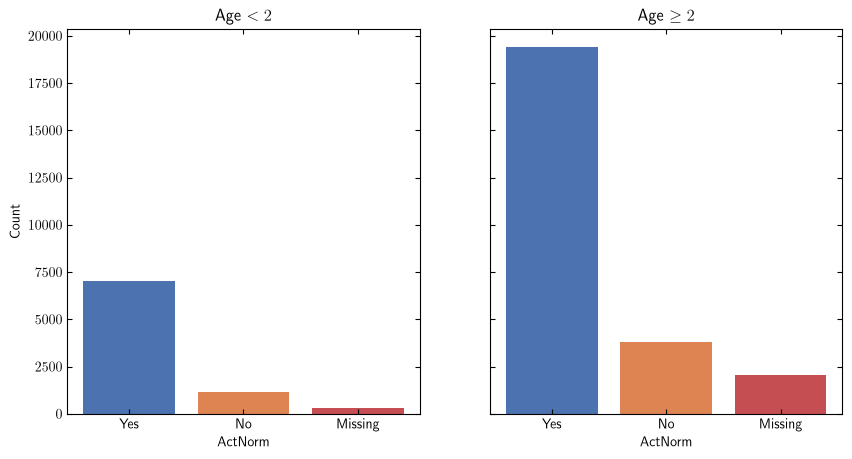

In [21]:
# Visualizing the distribution of ActNorm for both age groups, including missing values.

train_data_under_2['ActNorm'] = train_data_under_2['ActNorm'].replace(r'^\s*$', np.nan, regex=True)
train_data_over_2['ActNorm'] = train_data_over_2['ActNorm'].replace(r'^\s*$', np.nan, regex=True)

print(train_data_under_2['ActNorm'].isna().sum())
print(train_data_over_2['ActNorm'].isna().sum())

mapping = {1: 'Yes', 0: 'No'}
train_data_under_2['ActNorm'] = train_data_under_2['ActNorm'].replace(mapping)
train_data_over_2['ActNorm'] = train_data_over_2['ActNorm'].replace(mapping)

labels = ['Yes', 'No', 'Missing']

under_mapped = (
    train_data_under_2['ActNorm']
    .fillna('Missing')
    .value_counts()
    .reindex(labels, fill_value=0)
)

over_mapped = (
    train_data_over_2['ActNorm']
    .fillna('Missing')
    .value_counts()
    .reindex(labels, fill_value=0)
)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
colors = ['#4C72B0', '#DD8452', '#C44E52']

# Left Plot: Age < 2
ax[0].bar(labels, under_mapped, color=colors)
ax[0].set_title('Age $< 2$')
ax[0].set_xlabel('ActNorm')
ax[0].set_ylabel('Count')

# Right Plot: Age >= 2
ax[1].bar(labels, over_mapped, color=colors)
ax[1].set_title('Age $\\geq 2$')
ax[1].set_xlabel('ActNorm')

plt.savefig(dir / 'figs' / 'age_group_actnorm.png', dpi=300, bbox_inches='tight')
plt.show()


In [22]:
# Look at the proportion of missingness in the ActNorm column for both age groups

total_counts_under = under_mapped['Yes'] + under_mapped['No'] + under_mapped['Missing']
total_counts_over = over_mapped['Yes'] + over_mapped['No'] + over_mapped['Missing']

print(total_counts_under)
print(under_mapped['Missing'])
print(total_counts_over)

print(f"Proportion of missingness in ActNorm for Age < 2: {under_mapped['Missing'] / total_counts_under}")

print(f"Proportion of missingness in ActNorm for Age >= 2: {over_mapped['Missing'] / total_counts_over}")

8502
331
25283
Proportion of missingness in ActNorm for Age < 2: 0.03893201599623618
Proportion of missingness in ActNorm for Age >= 2: 0.08242692718427402


It appears that the proportion of ActNorm is similar between the two age groups, with a majority of patients having ActNorm = Yes, followed by No, and a small proportion of Missing values. The proportion of missing in the Age >= 2 group is slightly higher than in the Age < 2 group, but this difference is not substantial. Overall, the distribution of ActNorm seems consistent across both age groups. It is possible perhaps that there are more in the larger age group because older kids are more likely to arrive at the hospital wihtout a parent or guardian to specify whether they are acting normally or not, but this is just speculation. It is not meaningful to exclude patients who have a missing value, as there could be several reasons as to why this is the case. We also don't have the information to impute the missing values. One could probably make the claim that you could potentially use AMS to impute these values as an altered mental status would very likely not be normal, but due to my lack of expertise, I am not comfortable doing such an imputation. Thus, no further cleaning will be considered for the act normal variable.

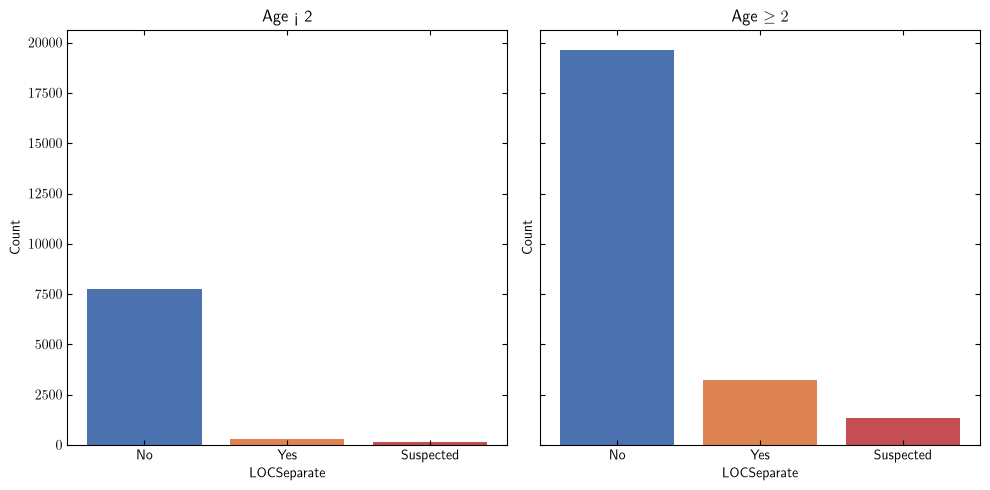

LOCSeparate
0    7772
1     273
2     150
Name: count, dtype: int64

LOCSeparate
0    19652
1     3224
2     1365
Name: count, dtype: int64

Number of suspected cases and how long they were unconscious in the < 2 age group:
LocLen
<5 seconds        29
5 sec - <1 min    50
1 - 5 min         19
4: >5 min          0
Unknown            0
Name: count, dtype: int64
Number of suspected cases and how long they were unconscious in the >= 2 age group:
LocLen
<5 seconds        273
5 sec - <1 min    308
1 - 5 min          67
4: >5 min           0
Unknown             0
Name: count, dtype: int64


In [23]:
# Create visual that shows the bar graph of LOCSeparate for 0 (No), 1 (Yes), and 2 (Suspected) for LOCSeparate for both age groups as subplots.

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].bar(['No', 'Yes', 'Suspected'], train_data_under_2['LOCSeparate'].value_counts().reindex([0, 1, 2], fill_value=0), color=['#4C72B0', '#DD8452', '#C44E52'])
ax[0].set_title('Age < 2')
ax[0].set_xlabel('LOCSeparate')
ax[0].set_ylabel('Count')

ax[1].bar(['No', 'Yes', 'Suspected'], train_data_over_2['LOCSeparate'].value_counts().reindex([0, 1, 2], fill_value=0), color=['#4C72B0', '#DD8452', '#C44E52'])
ax[1].set_title('Age $\\geq 2$')
ax[1].set_xlabel('LOCSeparate')
ax[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig(dir / 'figs' / 'loctotal_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

display(train_data_under_2['LOCSeparate'].value_counts().reindex([0, 1, 2], fill_value=0))
display(train_data_over_2['LOCSeparate'].value_counts().reindex([0, 1, 2], fill_value=0))

under_filtered = train_data_under_2[train_data_under_2['LOCSeparate'] == 2]
over_filtered = train_data_over_2[train_data_over_2['LOCSeparate'] == 2]

labels = ['<5 seconds', '5 sec - <1 min', '1 - 5 min', '4: >5 min', 'Unknown']
mapping = {1: '<5 seconds', 2: '5 sec - <1 min', 3: '1 - 5 min', 4: '>5 min', 92: 'Unknown'}

print(f"Number of suspected cases and how long they were unconscious in the < 2 age group:\n{under_filtered['LocLen'].map(mapping).value_counts().reindex(labels, fill_value=0)}")

print(f"Number of suspected cases and how long they were unconscious in the >= 2 age group:\n{over_filtered['LocLen'].map(mapping).value_counts().reindex(labels, fill_value=0)}")

Suspecting LOC, especially if a value of duration is reported, seems as though the patient did in fact lose consciousness, so I want to investigate if for the suspected LOC cases that having a duration, if we change their LOC status to Yes, does the distribution (relative proportion) change much. The logic behind this is: if someone or themselves notices a gap in consciousness and reports a duraton that this episode occurred, it is likely the event truly occurred.

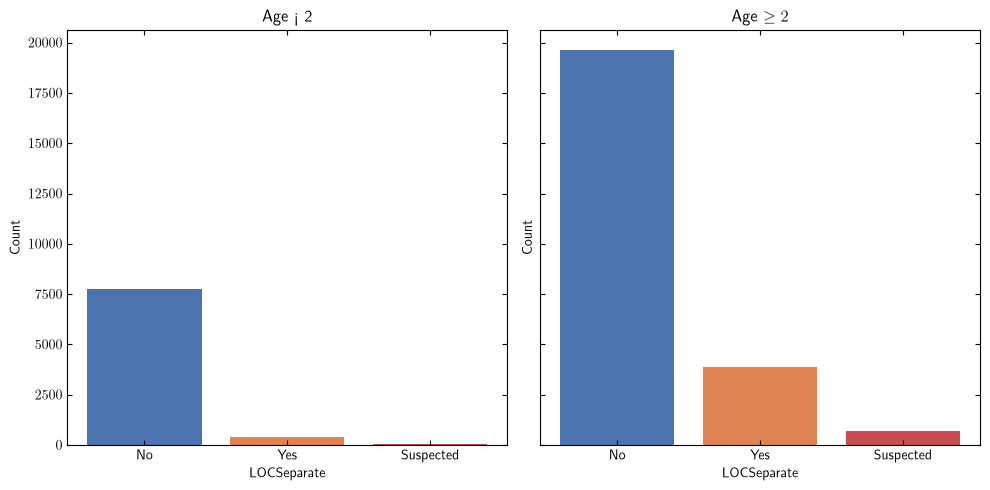

LOCSeparate
0    7772
1     387
2      36
Name: count, dtype: int64
LOCSeparate
0    19652
1     3883
2      706
Name: count, dtype: int64


In [24]:
# Create visual that shows the bar graph of LOCSeparate for 0 (No), 1 (Yes), and 2 (Suspected) for LOCSeparate for both age groups as subplots.

train_data_under_2_ = train_data_under_2.copy()
train_data_over_2_ = train_data_over_2.copy()

valid_loc_durations = [1, 2, 3, 4]

cond_under = train_data_under_2_['LocLen'].isin(valid_loc_durations)
cond_over = train_data_over_2_['LocLen'].isin(valid_loc_durations)

mask_under = (train_data_under_2_['LOCSeparate'] == 2) & cond_under
mask_over = (train_data_over_2_['LOCSeparate'] == 2) & cond_over

# Updates pateints who were suspected of LOC that had a duration as confirmation of LOC.
train_data_under_2_.loc[mask_under, 'LOCSeparate'] = 1
train_data_over_2_.loc[mask_over, 'LOCSeparate'] = 1

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].bar(['No', 'Yes', 'Suspected'], train_data_under_2_['LOCSeparate'].value_counts().reindex([0, 1, 2], fill_value=0), color=['#4C72B0', '#DD8452', '#C44E52'])
ax[0].set_title('Age < 2')
ax[0].set_xlabel('LOCSeparate')
ax[0].set_ylabel('Count')

ax[1].bar(['No', 'Yes', 'Suspected'], train_data_over_2_['LOCSeparate'].value_counts().reindex([0, 1, 2], fill_value=0), color=['#4C72B0', '#DD8452', '#C44E52'])
ax[1].set_title('Age $\\geq 2$')
ax[1].set_xlabel('LOCSeparate')
ax[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig(dir / 'figs' / 'loctotal_distribution_updated.png', dpi=300, bbox_inches='tight')
plt.show()

print(train_data_under_2_['LOCSeparate'].value_counts().reindex([0, 1, 2], fill_value=0))
print(train_data_over_2_['LOCSeparate'].value_counts().reindex([0, 1, 2], fill_value=0))

In [25]:
old_counts_under = train_data_under_2['LOCSeparate'].value_counts().reindex([0, 1, 2], fill_value=0)
old_counts_over = train_data_over_2['LOCSeparate'].value_counts().reindex([0, 1, 2], fill_value=0)
new_counts_under = train_data_under_2_['LOCSeparate'].value_counts().reindex([0, 1, 2], fill_value=0)
new_counts_over = train_data_over_2_['LOCSeparate'].value_counts().reindex([0, 1, 2], fill_value=0)

# Reshape counts into vectors to compare profiles
similarity = cosine_similarity([old_counts_under.values], [new_counts_under.values])[0][0]
print(f"Distribution Similarity Score: {similarity:.4f}")

similarity = cosine_similarity([old_counts_over.values], [new_counts_over.values])[0][0]
print(f"Distribution Similarity Score: {similarity:.4f}")



Distribution Similarity Score: 0.9998
Distribution Similarity Score: 0.9989


After changing a patients LOCSeparate from 2 (Suspected) to 1 (Yes) based on their LOC duration, we can see that the distribution of LOCSeparate has changed slightly (to be expected), but I want to see if this significantly changes the distribution (relative proportions) or not. If it does not, then I will clean the LOCSeparate variable in this way. If it does, then I will not clean the variable in this way. To check whether this adjustment drastically altered the variable's profile, I treated the category counts before and after the change as vectors and calculated their cosine similarity. Since both cosine simialrity scores are close to 1, we can conclude the variable's relative proportions remain highly stable. Thus, cleaning the variable in this manner does not distort the underlying data structure. But, I will allow this decision to be a perturbation. Kuppermann combines 'Yes' and 'Suspected' in to one for all patients. I, however, lacking subject matter expertise do not want to blindly follow this step. We don't have the information available to, with 100% certainty, ascertain that a suspected LOC is truly a LOC.

In [26]:
train_data_under_2_loc_cleaned = clean_loc(train_data_under_2_ha_cleaned)
train_data_over_2_loc_cleaned = clean_loc(train_data_over_2_ha_cleaned)

The above code cleans LOC so that if the patient is suspected of having LOC but has a duration, they are confirmed to have LOC. If suspected = False, then LOCSeparate is unchanged. Empty cells are changed to np.nan for consistency and the column is renamed to LOC. We do not change LOC if LOC = 1 but LocLen is missing or = 92, as this could be indicative of many things, namely the patient not knowing how long they were unconscious for, or the patient being nonverbal/preverbal and unable to report how long they were unconscious for. We do not want to make assumptions about these patients.

In [27]:
# This script creates a contingency table of Injury Mechanism and Injury Severity for two age groups: Age < 2 and Age >= 2.

mech_mapping = {
    1: 'MVC', 2: 'Pedestrian', 3: 'Bicycle by Vehicle', 4: 'Bicycle', 
    5: 'Other Wheeled Transport', 6: 'Fall', 7: 'Walk', 8: 'Elevation', 
    9: 'Stairs', 10: 'Sports', 11: 'Assault', 12: 'Object - Accidental', 90: 'Other'
}
sev_mapping = {1: 'Low', 2: 'Moderate', 3: 'High'}

print("Age < 2")
df_under_2 = train_data_under_2[['InjuryMech', 'High_impact_InjSev']].copy()
df_under_2['Mechanism'] = df_under_2['InjuryMech'].map(mech_mapping)
df_under_2['Severity'] = df_under_2['High_impact_InjSev'].map(sev_mapping)

ct_under_2 = pd.crosstab(
    df_under_2['Mechanism'], 
    df_under_2['Severity'], 
    margins=True, 
    margins_name="Total"
).reindex(index=list(mech_mapping.values()) + ['Total'], 
          columns=list(sev_mapping.values()) + ['Total'], 
          fill_value=0)

print(ct_under_2)


print("\nAge >= 2")
df_over_2 = train_data_over_2[['InjuryMech', 'High_impact_InjSev']].copy()
df_over_2['Mechanism'] = df_over_2['InjuryMech'].map(mech_mapping)
df_over_2['Severity'] = df_over_2['High_impact_InjSev'].map(sev_mapping)

ct_over_2 = pd.crosstab(
    df_over_2['Mechanism'], 
    df_over_2['Severity'], 
    margins=True, 
    margins_name="Total"
).reindex(index=list(mech_mapping.values()) + ['Total'], 
          columns=list(sev_mapping.values()) + ['Total'], 
          fill_value=0)

print(ct_over_2)


Age < 2
Severity                  Low  Moderate  High  Total
Mechanism                                           
MVC                         0       169    29    198
Pedestrian                  0         8    32     40
Bicycle by Vehicle          0         1     2      3
Bicycle                     0        10     0     10
Other Wheeled Transport     0        37     0     37
Fall                      773         0     0    773
Walk                      474         0     0    474
Elevation                   0      2828  1782   4610
Stairs                      0      1193     0   1193
Sports                      0         5     1      6
Assault                     0        55     0     55
Object - Accidental         0       399    13    412
Other                       0       606     1    607
Total                    1247      5311  1860   8418

Age >= 2
Severity                  Low  Moderate  High  Total
Mechanism                                           
MVC                         

In [28]:
def find_unlabeled_rows(df, age_group_name):
    # Find rows where InjuryMech is present but High_impact_InjSev is missing or not 1, 2, 3
    missing_mask = (
        df['InjuryMech'].notna() & 
        (df['High_impact_InjSev'].isna() | ~df['High_impact_InjSev'].isin([1, 2, 3]))
    )
    
    missing_data = df[missing_mask]
    
    print(f"\nFound {len(missing_data)} missing severity labels in: {age_group_name}")
    if len(missing_data) > 0:
        # Display Row Index, InjuryMech code, and existing severity if any
        print(missing_data[['InjuryMech', 'High_impact_InjSev']])
    return missing_mask

missing_under_2_mask = find_unlabeled_rows(train_data_under_2, "Age < 2 Years")
missing_over_2_mask = find_unlabeled_rows(train_data_over_2, "Age >= 2 Years")



Found 1 missing severity labels in: Age < 2 Years
       InjuryMech  High_impact_InjSev
23526         2.0                 NaN

Found 25 missing severity labels in: Age >= 2 Years
       InjuryMech  High_impact_InjSev
3474          2.0                 NaN
5790          2.0                 NaN
7107          2.0                 NaN
7285          2.0                 NaN
7415          2.0                 NaN
9328          2.0                 NaN
13828         2.0                 NaN
13965         2.0                 NaN
15399         2.0                 NaN
16570         2.0                 NaN
20507         2.0                 NaN
22314         2.0                 NaN
24887         2.0                 NaN
25287         2.0                 NaN
27842         2.0                 NaN
27892         2.0                 NaN
28425         2.0                 NaN
28641         2.0                 NaN
28853         2.0                 NaN
28887         2.0                 NaN
29977         2.0     

It appears that all of the values missing in the High_impact_InjSev have corresponding InjuryMech value of 2, pedestrian struck by a moving vehicle. I found this to be interesting because in both age groups, some 2s are mapped to a severity label while some are not. I think it is worth trying to make the judgment call to assign these patients a severity label. It is also of note that in both age groups, some 2s were mapped to moderate and some to high. It is more evident in the older group that a larger proportion of the 2s were mapped to high severity. With this in mind, I think it is reasonable to assign the missing severity labels for InjuryMech = 2 to high severity. In order to check this, after making the change (if InjMech = 2 and High_impact_InjSev is missing, assign High_impact_InjSev = 3), I will again vectorize the counts and use cosine similarity. It is also of note that the mechanism that results in a specific injury severity is not as cut-throat as one might think. For example, a fall can result in a low, moderate, or high severity injury depending on the circumstances of the fall (height, surface, etc.). Similarly, a motor vehicle collision (MVC) can also result in varying severities of injury. So, we cannot simply assume a injury mechanism will always result in a specific injury severity. 

In [29]:
# Changes the missing severity labels for InjuryMech = 2 (Pedestrian) to High_impact_InjSev = 3 (High) for both age groups if orginally missing.

missing_under_2_sev_mask = train_data_under_2['InjuryMech'].eq(2) & train_data_under_2['High_impact_InjSev'].isna()
missing_over_2_sev_mask = train_data_over_2['InjuryMech'].eq(2) & train_data_over_2['High_impact_InjSev'].isna()

train_data_under_2_sev = train_data_under_2.copy()
train_data_under_2_sev.loc[missing_under_2_sev_mask, 'High_impact_InjSev'] = 3
train_data_over_2_sev = train_data_over_2.copy()
train_data_over_2.loc[missing_over_2_sev_mask, 'High_impact_InjSev'] = 3

import pandas as pd

mech_mapping = {
    1: 'MVC', 2: 'Pedestrian', 3: 'Bicycle by Vehicle', 4: 'Bicycle', 
    5: 'Other Wheeled Transport', 6: 'Fall', 7: 'Walk', 8: 'Elevation', 
    9: 'Stairs', 10: 'Sports', 11: 'Assault', 12: 'Object - Accidental', 90: 'Other'
}
sev_mapping = {1: 'Low', 2: 'Moderate', 3: 'High'}

#print("Age < 2")
df_under_2 = train_data_under_2_sev[['InjuryMech', 'High_impact_InjSev']].copy()
df_under_2['Mechanism'] = df_under_2['InjuryMech'].map(mech_mapping)
df_under_2['Severity'] = df_under_2['High_impact_InjSev'].map(sev_mapping)

ct_under_2 = pd.crosstab(
    df_under_2['Mechanism'], 
    df_under_2['Severity'], 
    margins=True, 
    margins_name="Total"
).reindex(index=list(mech_mapping.values()) + ['Total'], 
          columns=list(sev_mapping.values()) + ['Total'], 
          fill_value=0)

print(ct_under_2)


print("\nAge >= 2")
df_over_2 = train_data_over_2_sev[['InjuryMech', 'High_impact_InjSev']].copy()
df_over_2['Mechanism'] = df_over_2['InjuryMech'].map(mech_mapping)
df_over_2['Severity'] = df_over_2['High_impact_InjSev'].map(sev_mapping)

ct_over_2 = pd.crosstab(
    df_over_2['Mechanism'], 
    df_over_2['Severity'], 
    margins=True, 
    margins_name="Total"
).reindex(index=list(mech_mapping.values()) + ['Total'], 
          columns=list(sev_mapping.values()) + ['Total'], 
          fill_value=0)

print(ct_over_2)

old_counts_under_sev = train_data_under_2[train_data_under_2['InjuryMech'] == 2]['High_impact_InjSev'].value_counts().reindex([1, 2, 3], fill_value=0)
old_counts_over_sev = train_data_over_2[train_data_over_2['InjuryMech'] == 2]['High_impact_InjSev'].value_counts().reindex([1, 2, 3], fill_value=0)
new_counts_under_sev = train_data_under_2_sev[train_data_under_2_sev['InjuryMech'] == 2]['High_impact_InjSev'].value_counts().reindex([1, 2, 3], fill_value=0)
new_counts_over_sev = train_data_over_2_sev[train_data_over_2_sev['InjuryMech'] == 2]['High_impact_InjSev'].value_counts().reindex([1, 2, 3], fill_value=0)

print("Old counts (under 2):")
print(old_counts_under_sev)
print("New counts (under 2):")
print(new_counts_under_sev)
print("Old counts (over 2):")
print(old_counts_over_sev)
print("New counts (over 2):")
print(new_counts_over_sev)

from sklearn.metrics.pairwise import cosine_similarity

# Reshape counts into vectors to compare profiles
similarity = cosine_similarity([old_counts_under_sev.values], [new_counts_under_sev.values])[0][0]
print(f"Distribution Similarity Score: {similarity:.4f} (1.0 means identical distribution proportions)")

similarity = cosine_similarity([old_counts_over_sev.values], [new_counts_over_sev.values])[0][0]
print(f"Distribution Similarity Score: {similarity:.4f} (1.0 means identical distribution proportions)")


Severity                  Low  Moderate  High  Total
Mechanism                                           
MVC                         0       169    29    198
Pedestrian                  0         8    33     41
Bicycle by Vehicle          0         1     2      3
Bicycle                     0        10     0     10
Other Wheeled Transport     0        37     0     37
Fall                      773         0     0    773
Walk                      474         0     0    474
Elevation                   0      2828  1782   4610
Stairs                      0      1193     0   1193
Sports                      0         5     1      6
Assault                     0        55     0     55
Object - Accidental         0       399    13    412
Other                       0       606     1    607
Total                    1247      5311  1861   8419

Age >= 2
Severity                  Low  Moderate  High  Total
Mechanism                                           
MVC                         0      2

Since, when adding in the patients with mechanism 2 and missing severirty values to the "High" severity group,  the relative proportions remain stable, doing this data cleaing step is validated (Adds 1 patient to high sev group when mech = 2 and age < 2, adds 25 patients to high sev group when mech = 2 and age >= 2).

In [30]:
train_data_under_2_clean_sev = clean_injury_severity(train_data_under_2_loc_cleaned)
train_data_over_2_clean_sev = clean_injury_severity(train_data_over_2_loc_cleaned)

As mentioned above, I am making the patients who were a pedestrian hit by a moving car with a missing severity category, a high severity injury. I have also allowed this cleaning step to be a perturbation as my grounds for doing this was to try to handle mechanisms who did not have a severity category (was not based on domain knowledge), but I obviously do not actually know the severity of these patients. I am just trying to make a best-guess off of the relative frequencies for that mechanism prior to the change. Again, I am not imputing any missing values. Throughout this cleaning process, if I could not directly impute a missing value from sub-categories or do small amounts of "imputation" to try to solve a data miss-match issue, data was left as missing. Since the data is from hospitals, I can infer that the data is missing for a reason and imputing data is wrong since TBI is a case-by-case like injury. All '92s' were also changed to NaNs so that the models handle them correctly.

In [31]:
# Clean training data using the full clean version just for consistency and to ensure that all cleaning steps are applied in the correct order for comparison to perturbation cleaning and their resulting analyses.

train_data_under_2_cleaned = clean(reduced_train_data_under_2)
train_data_over_2_cleaned = clean(reduced_train_data_over_2)

## EDA Findings

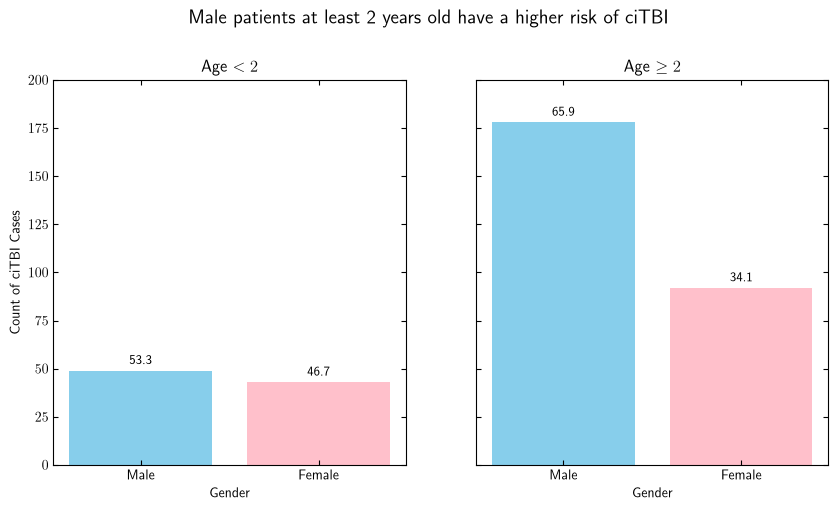

In [32]:
plt.rc('text', usetex=True)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

# Use .values to prevent pandas/matplotlib index alignment bugs
under_counts = (
    train_data_under_2_cleaned[train_data_under_2_cleaned['ciTBI'] == 'Yes']['Gender']
    .value_counts()
    .reindex([1, 2], fill_value=0)
    .values
)

over_counts = (
    train_data_over_2_cleaned[train_data_over_2_cleaned['ciTBI'] == 'Yes']['Gender']
    .value_counts()
    .reindex([1, 2], fill_value=0)
    .values
)

ax[0].set_ylim(0, 200)

# Plot Age < 2
bars_under = ax[0].bar(['Male', 'Female'], under_counts, color=['skyblue', 'pink'])
ax[0].set_title(r'Age $< 2$')
ax[0].set_xlabel('Gender')
ax[0].set_ylabel('Count of ciTBI Cases')

total_under = under_counts.sum()
under_proportions = [f'{v/total_under:.1%}' if total_under > 0 else '0.0%' for v in under_counts]
ax[0].bar_label(bars_under, labels=under_proportions, padding=3, fontsize=9)

# Plot Age >= 2
bars_over =ax[1].bar(['Male', 'Female'], over_counts, color=['skyblue', 'pink'])
ax[1].set_title(r'Age $\geq 2$')
ax[1].set_xlabel('Gender')

total_over = over_counts.sum()
over_proportions = [f'{v/total_over:.1%}' if total_over > 0 else '0.0%' for v in over_counts]
ax[1].bar_label(bars_over, labels=over_proportions, padding=3, fontsize=9)

fig.suptitle(r'Male patients at least 2 years old have a higher risk of ciTBI', fontsize=14, y=1.02)

plt.savefig(dir / 'figs' / 'finding_1.png', dpi=300, bbox_inches='tight')
plt.show()

Findings 1: In the <2 age groups, the proportion of ciTBI cases is pretty similar between female and male; whereas, in the >=2 age group, the proportion of ciTBI cases is higher in males than females. This could indicate that gender could (emphasis on could, need further analysis) be meaningful in terms of prediction of ciTBI (potentially bettering the CDR). The same behavior was note in Sonnergvist (2020) using the same PEARCN data (60.6% of patients with ciTBI are male).

ciTBI,No,Yes
LOC,,
0,0.949938,0.779221
1,0.045612,0.220779
2,0.004450,0.000000


ciTBI,No,Yes
LOC,,
0,0.815969,0.412766
1,0.156090,0.455319
2,0.027941,0.131915


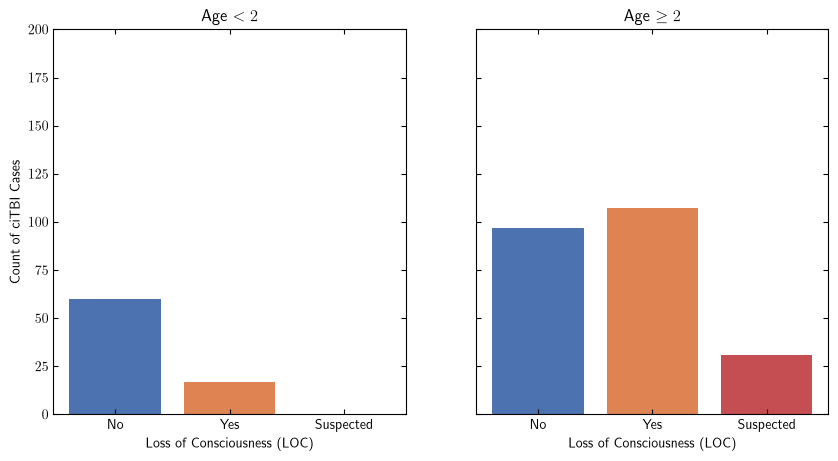

In [33]:
# Look at the proportion of LOC when ciTBI = Yes and ciTBI = No for both age groups via a contingency table.
# It is noted that the proportion of ciTBI = Yes in <2 is more concentrated for LOC = 0 (No) then for patients in the >=2 age group, which is more evenly concentrated between LOC = 0 (No) and LOC = 1 (Yes).
# Do a z-test for proportions to see if the difference in proportions of LOC = 0 (No) between the two age groups is statistically significant.
# Create a bar graph of LOC for 0 (No), 1 (Yes), and 2 (Suspected) for LOC for both age groups as subplots, but only for patients with ciTBI = Yes.

proportions_under = pd.crosstab(
    train_data_under_2_cleaned['LOC'],
    train_data_under_2_cleaned['ciTBI'],
    normalize='columns'
).reindex(index=[0, 1, 2], fill_value=0)

display(proportions_under)

proportions_over = pd.crosstab(
    train_data_over_2_cleaned['LOC'],
    train_data_over_2_cleaned['ciTBI'],
    normalize='columns'
).reindex(index=[0, 1, 2], fill_value=0)

display(proportions_over)

plt.rc('text', usetex=True)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

loc_counts_under = (
    train_data_under_2_cleaned[train_data_under_2_cleaned['ciTBI'] == 'Yes']['LOC']
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
    .values
)

loc_counts_over = (
    train_data_over_2_cleaned[train_data_over_2_cleaned['ciTBI'] == 'Yes']['LOC']
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
    .values
)

ax[0].bar(['No', 'Yes', 'Suspected'], loc_counts_under, color=['#4C72B0', '#DD8452', '#C44E52'])
ax[0].set_ylim(0, 200)
ax[0].set_xticks([0, 1, 2])
ax[0].set_xticklabels(['No', 'Yes', 'Suspected'])
ax[0].set_title(r'Age $< 2$')
ax[0].set_xlabel('Loss of Consciousness (LOC)')
ax[0].set_ylabel('Count of ciTBI Cases')

ax[1].bar(['No', 'Yes', 'Suspected'], loc_counts_over, color=['#4C72B0', '#DD8452', '#C44E52'])
ax[1].set_ylim(0, 200)
ax[1].set_xticks([0, 1, 2])
ax[1].set_xticklabels(['No', 'Yes', 'Suspected'])
ax[1].set_title(r'Age $\geq 2$')
ax[1].set_xlabel('Loss of Consciousness (LOC)')

plt.savefig(dir / 'figs' / 'loc_by_age_group.png', dpi=300, bbox_inches='tight')
plt.show()


When looking at the contingency tables between LOC and ciTBI for both ages, it is observed that the proportion of patients with LOC = 0 (No) is higher in the <2 age group compared to the >=2 age group. The z-test for proportions confirms that this difference is statistically significant, as indicated by the calculated z-statistic and p-value. I found this finding to actually be interesting. It is possible that this is due to the fact that younger patients may have a different physiological response to head trauma, or it could be related to differences in how LOC is assessed or reported in younger children. Further investigation into the underlying reasons for this difference would be valuable for clinical understanding and management of pediatric head injuries.

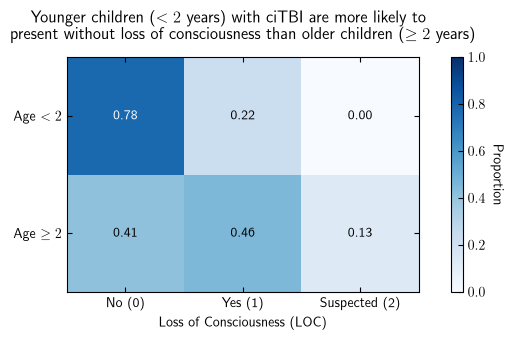

In [34]:

# Combine proportions into a single 2x3 matrix for ciTBI == 'Yes'
matrix_data = np.array([
    train_data_under_2_cleaned[
        train_data_under_2_cleaned['ciTBI'] == 'Yes'
    ]['LOC']
    .value_counts(normalize=True)
    .reindex([0, 1, 2], fill_value=0)
    .values,
    train_data_over_2_cleaned[
        train_data_over_2_cleaned['ciTBI'] == 'Yes'
    ]['LOC']
    .value_counts(normalize=True)
    .reindex([0, 1, 2], fill_value=0)
    .values,
])

fig, ax = plt.subplots(figsize=(7, 3.5))

im = ax.imshow(matrix_data, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(np.arange(3))
ax.set_yticks(np.arange(2))
ax.set_xticklabels(['No (0)', 'Yes (1)', 'Suspected (2)'])
ax.set_yticklabels([r'Age $< 2$', r'Age $\geq 2$'])

ax.set_xlabel('Loss of Consciousness (LOC)')
ax.set_title(r'Younger children ($< 2$ years) with ciTBI are more likely to \\present without loss of consciousness than older children ($\geq 2$ years)', pad=25)

# Annotate each cell with the exact proportion value
for i in range(2):
  for j in range(3):
    text = ax.text(
        j,
        i,
        f'{matrix_data[i, j]:.2f}',
        ha='center',
        va='center',
        color='white' if matrix_data[i, j] > 0.5 else 'black',
        fontweight='bold',
    )

cbar = ax.figure.colorbar(im, ax=ax)
cbar.set_label('Proportion', rotation=-90, va='bottom')

plt.savefig(dir / 'figs' / 'loss_of_consciousness.png', dpi=300, bbox_inches='tight')
plt.tight_layout()

Finding used in stability check: Younger children (< 2 years) with ciTBI are more likely to present without loss of consciousness than older children (≥ 2 years). This is likely due to the fact that younger children have less developed neurological systems and may not exhibit the same symptoms as older children when experiencing a traumatic brain injury. This is indicative that the two age groups should in fact be treated as separate populations when analyzing the risk factors and outcomes associated with ciTBI.

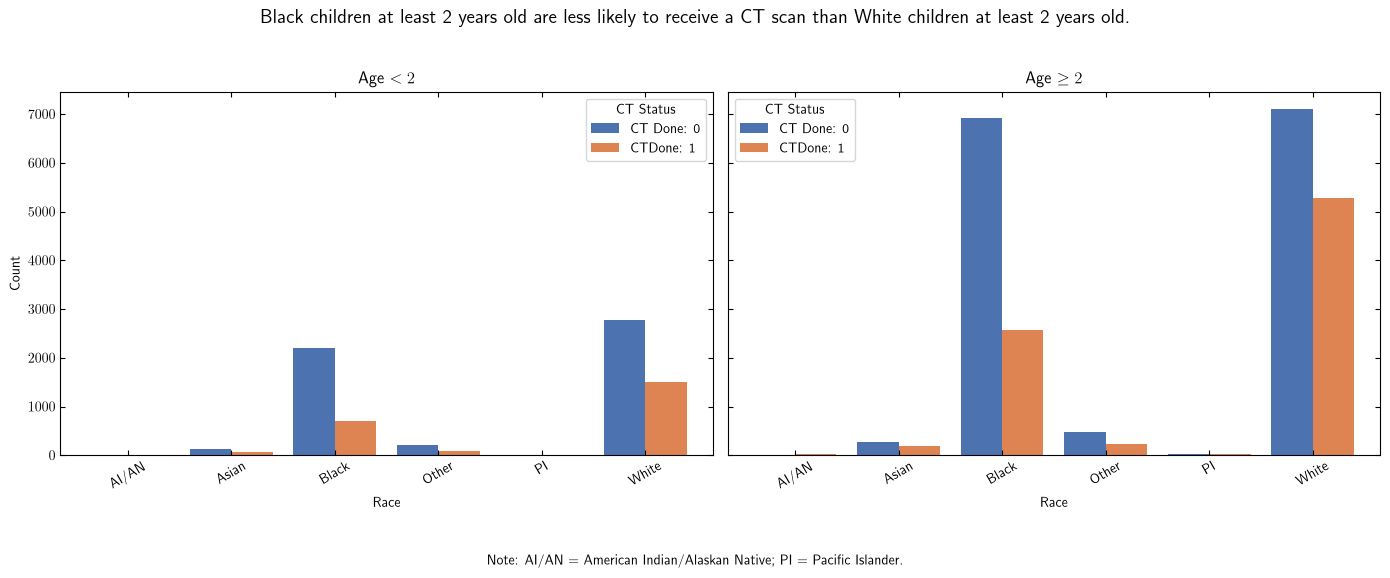

In [35]:
# figure that looks at the dsitrbtion of 'CTDone' over 'Race' and age group


race_mapping = {
    1: 'White',
    2: 'Black',
    3: 'Asian',
    4: 'AI/AN', # Abbreviated as AI/AN
    5: 'PI',  # Abbreviated as PI
    90: 'Other',
}

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

race_under_2 = train_data_under_2_cleaned['Race'].map(race_mapping)
ct_under_2 = pd.crosstab(race_under_2, train_data_under_2_cleaned['CTDone'])

race_over_2 = train_data_over_2_cleaned['Race'].map(race_mapping)
ct_over_2 = pd.crosstab(race_over_2, train_data_over_2_cleaned['CTDone'])

# 2. Plot Age < 2
ct_under_2.plot(
    kind='bar', ax=ax[0], color=['#4C72B0', '#DD8452'], width=0.8
)
ax[0].set_title(r'Age $< 2$')
ax[0].set_xlabel('Race')
ax[0].set_ylabel('Count')
ax[0].legend(['CT Done: 0', 'CTDone: 1'], title='CT Status')
ax[0].tick_params(axis='x', rotation=30)

# 3. Plot Age >= 2
ct_over_2.plot(kind='bar', ax=ax[1], color=['#4C72B0', '#DD8452'], width=0.8)
ax[1].set_title(r'Age $\geq 2$')
ax[1].set_xlabel('Race')
ax[1].set_ylabel('Count')
ax[1].legend(['CT Done: 0', 'CTDone: 1'], title='CT Status')
ax[1].tick_params(axis='x', rotation=30)

fig.suptitle(
    'Black children at least 2 years old are less likely to receive a CT scan than White children at least 2 years old.',
    fontsize=14,
    y=1.03,
)

fig.text(
    0.5,
    -0.08,
    'Note: AI/AN = American Indian/Alaskan Native; PI = Pacific Islander.',
    ha='center',
    fontsize=10,
    style='italic',
)

plt.tight_layout()
plt.savefig(dir / 'figs' / 'finding_2.png', dpi=300, bbox_inches='tight')
plt.show()

## Reality Check

Firstly, as shown in EDA, it was checked that GCS values lie within the expected range of 3 to 15, grounding the data in what is clinically plausible. One data cleaning step involved changing any subjects LOC feature if they were suspected of having LOC (LOCSeparate = 2) but had a known duration of LOC (LocLen in [1, 2, 3, 4]) to confirmed LOC (LOCSeparate = 1). This was done to ensure that the data accurately reflected the clinical reality of the patients' conditions. If someone suspected of LOC had a known duration, it is reasonable to classify them as having experienced LOC. This step was crucial for maintaining the integrity of the dataset and ensuring that subsequent analyses were based on accurate representations of patient conditions.

In [36]:
# Display the counts of Injury Mechanism for patients under 2 years old and at least 2 years old after cleaning the data.

under_2_inj_mech_counts = train_data_under_2_cleaned['InjuryMech'].value_counts().sort_index()
display(under_2_inj_mech_counts)

over_2_inj_mech_counts = train_data_over_2_cleaned['InjuryMech'].value_counts().sort_index()
display(over_2_inj_mech_counts)

InjuryMech
1.0      197
2.0       41
3.0        3
4.0       10
5.0       37
6.0      768
7.0      472
8.0     4600
9.0     1186
10.0       6
11.0      55
12.0     412
90.0     602
Name: count, dtype: int64

InjuryMech
1.0     2762
2.0      991
3.0      416
4.0     1299
5.0      628
6.0     2887
7.0     1423
8.0     4630
9.0     1060
10.0    2228
11.0    2316
12.0    2074
90.0    2028
Name: count, dtype: int64

The above table shows the counts of injury mechanisms for patients under 2 years old after cleaning the data. We see that 'InjMech' == 3 has a very low count, which makes sense since children under two do not know how to ride a bicycle, and thus we wouldn't expect many of this injury. It is possible that the few cases of 'InjMech' == 3 could be due to the child riding with a parent or guardian (but worth noting they could also be misclassified). The same logic can be applied to when 'InjMech' == 4, injury due to bicycle collision. It is of note that while we have a few cases of unanticipated behavior for children under 2, the count is substantially small, especially when considering what the count is in those categories for children at least 2 years olf (a population that is expected to see children riding a bike). We also see similar behavior for 'InjMech' == 10, injury from sports. Most children sports teams start around the age of 5, so we would not expect to see many cases of sports injuries.

Lastly, the other judgment call made was changing the severity of injury for patients who were pedestrians (InjuryMech = 2) and had a missing severity label to High (High_impact_InjSev = 3). This was done because pedestrians are generally considered to be at high risk for severe injury when involved in a collision with a vehicle. The change was made for both age groups, and the distribution of severity labels was compared before and after the change to ensure that the overall distribution remained similar.

## Stability Check

In [37]:
cleaned_stab_check_under_2 = clean(reduced_train_data_under_2, gcs_total = False, suspected = False, new_severity = False)
cleaned_stab_check_over_2 = clean(reduced_train_data_over_2, gcs_total = False, suspected = False, new_severity = False)

To do the stability check, as documented through the paper, we instead clean the data by using the sum of the components for GCS to clean AMS, we do not change suspected LOC to confirmed LOC, and we do not change the severity of the injury when the mechanism is 2 (pedestrian struck by moving car) and the severity was orginally missing--the severity stays missing. This is to ensure the judgement calls we made doesn't change the results we should be drawing from the data. Below, we will compare the finding 2 when we perturb the cleaning process.

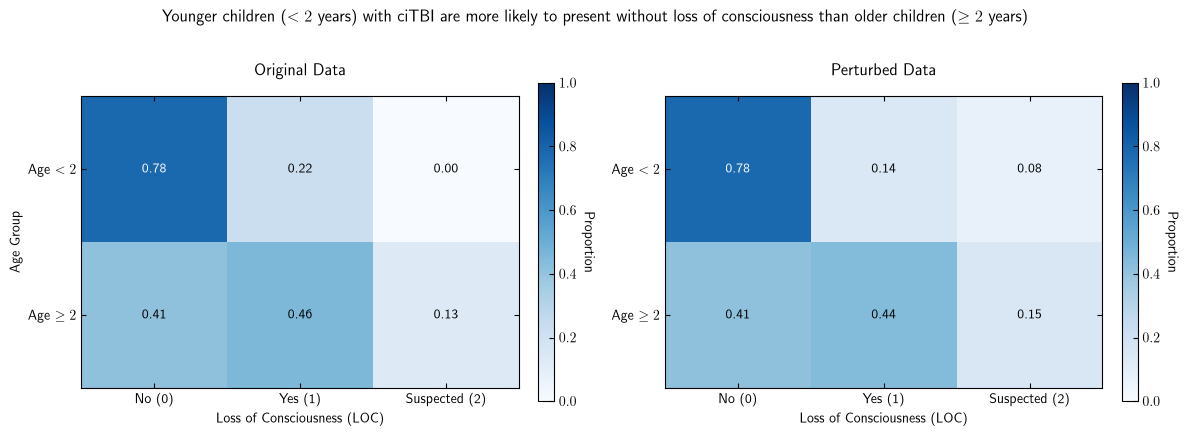

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

matrix_data_orig = np.array([
    train_data_under_2_cleaned[
        train_data_under_2_cleaned['ciTBI'] == 'Yes'
    ]['LOC']
    .value_counts(normalize=True)
    .reindex([0, 1, 2], fill_value=0)
    .values,
    train_data_over_2_cleaned[
        train_data_over_2_cleaned['ciTBI'] == 'Yes'
    ]['LOC']
    .value_counts(normalize=True)
    .reindex([0, 1, 2], fill_value=0)
    .values,
])

im0 = ax[0].imshow(matrix_data_orig, cmap='Blues', vmin=0, vmax=1)

ax[0].set_xticks(np.arange(3))
ax[0].set_yticks(np.arange(2))
ax[0].set_xticklabels(['No (0)', 'Yes (1)', 'Suspected (2)'])
ax[0].set_yticklabels([r'Age $< 2$', r'Age $\geq 2$'])
ax[0].set_xlabel('Loss of Consciousness (LOC)')
ax[0].set_ylabel('Age Group')
ax[0].set_title('Original Data', pad=15)

for i in range(2):
  for j in range(3):
    ax[0].text(
        j,
        i,
        f'{matrix_data_orig[i, j]:.2f}',
        ha='center',
        va='center',
        color='white' if matrix_data_orig[i, j] > 0.5 else 'black',
        fontweight='bold',
    )

cbar0 = fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
cbar0.set_label('Proportion', rotation=-90, va='bottom')

matrix_data_pert = np.array([
    cleaned_stab_check_under_2[
        cleaned_stab_check_under_2['ciTBI'] == 'Yes'
    ]['LOC']
    .value_counts(normalize=True)
    .reindex([0, 1, 2], fill_value=0)
    .values,
    cleaned_stab_check_over_2[
        cleaned_stab_check_over_2['ciTBI'] == 'Yes'
    ]['LOC']
    .value_counts(normalize=True)
    .reindex([0, 1, 2], fill_value=0)
    .values,
])

im1 = ax[1].imshow(matrix_data_pert, cmap='Blues', vmin=0, vmax=1)

ax[1].set_xticks(np.arange(3))
ax[1].set_yticks(np.arange(2))
ax[1].set_xticklabels(['No (0)', 'Yes (1)', 'Suspected (2)'])
ax[1].set_yticklabels([r'Age $< 2$', r'Age $\geq 2$'])
ax[1].set_xlabel('Loss of Consciousness (LOC)')
ax[1].set_title('Perturbed Data', pad=15)

for i in range(2):
  for j in range(3):
    ax[1].text(
        j,
        i,
        f'{matrix_data_pert[i, j]:.2f}',
        ha='center',
        va='center',
        color='white' if matrix_data_pert[i, j] > 0.5 else 'black',
        fontweight='bold',
    )

cbar1 = fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
cbar1.set_label('Proportion', rotation=-90, va='bottom')


fig.suptitle(
    r'Younger children ($< 2$ years) with ciTBI are more likely to '
    r'present without loss of consciousness than older children ($\geq 2$ years)',
    y=1.05,
)

plt.tight_layout()
plt.savefig(dir / 'figs' / 'findings_perturbed.png', dpi=300, bbox_inches='tight')
plt.show()

When looking at the heatmap after perturbing the data, we see that same result as found in the original cleaned data (using the original judgment calls). This is indicative that the main judgement calls used does not change the underlying data relationships, and that the findings are robust to perturbations in the data cleaning process.

## Modeling

Optimal max_depth for under 2 yrs: 2
Optimal max_depth for at least 2 yrs: 2


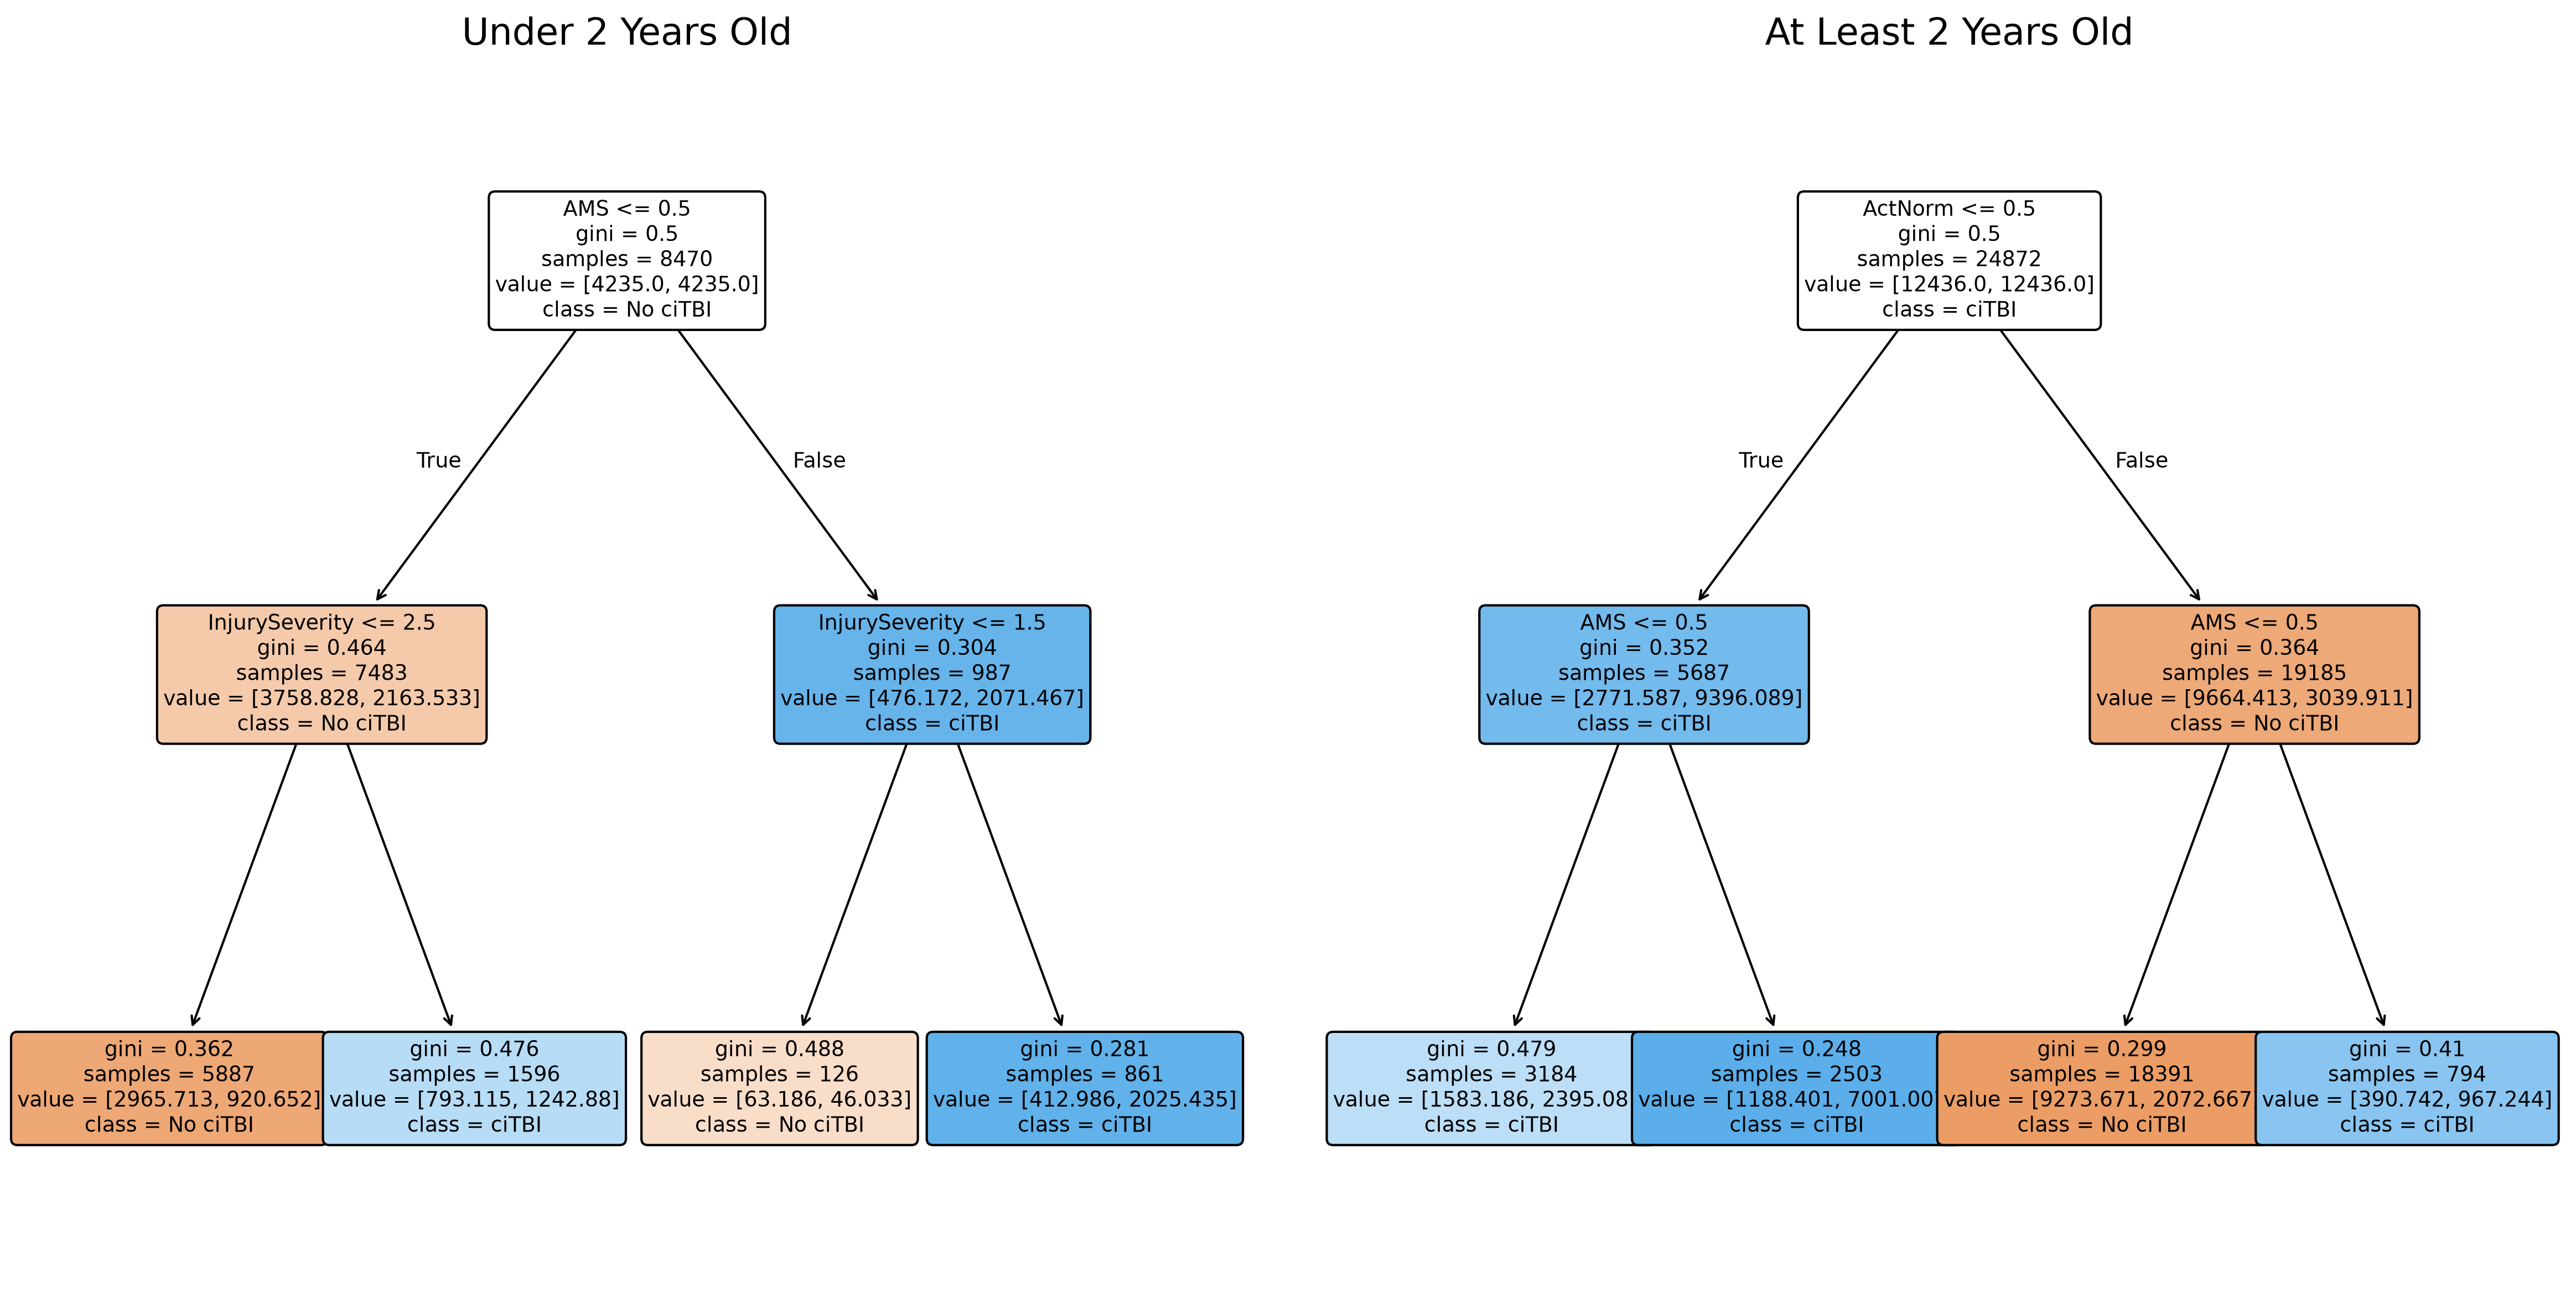

In [39]:
# Model 1: Decision Tree Classifier for Age < 2 and Age >= 2 groups using cleaned data. To learn hyperparameter 'max_depth', use CV to find optimal value

X_train_under_2 = train_data_under_2_cleaned.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()
for col in X_train_under_2.columns:
    if X_train_under_2[col].dtype == 'object':
        if X_train_under_2[col].nunique() == 2:
            # Convert 'Yes'/'No' to 1/0
            X_train_under_2[col] = X_train_under_2[col].map({'Yes': 1, 'No': 0})
        elif X_train_under_2[col].nunique() > 2:
                    # Convert categorical variables to ordinal
                    X_train_under_2[col] = pd.Categorical(X_train_under_2[col]).codes

X_train_over_2 = train_data_over_2_cleaned.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()
for col in X_train_over_2.columns:
    if X_train_over_2[col].dtype == 'object':
        if X_train_over_2[col].nunique() == 2:
            # Convert 'Yes'/'No' to 1/0
            X_train_over_2[col] = X_train_over_2[col].map({'Yes': 1, 'No': 0})
        elif X_train_over_2[col].nunique() > 2:
            # Convert categorical variables to ordinal
            X_train_over_2[col] = pd.Categorical(X_train_over_2[col]).codes

    y_train_binary_under = train_data_under_2_cleaned['ciTBI'].map({'Yes': 1, 'No': 0})
    y_train_binary_over = train_data_over_2_cleaned['ciTBI'].map({'Yes': 1, 'No': 0})

param_grid = {'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10]}

cv_under_2 = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=10)
cv_under_2.fit(X_train_under_2, y_train_binary_under)

cv_over_2 = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=10)
cv_over_2.fit(X_train_over_2, y_train_binary_over)

print(f"Optimal max_depth for under 2 yrs: {cv_under_2.best_params_['max_depth']}")
print(f"Optimal max_depth for at least 2 yrs: {cv_over_2.best_params_['max_depth']}")

under_2_best_depth = cv_under_2.best_params_['max_depth']
over_2_best_depth = cv_over_2.best_params_['max_depth']

dec_tree_under_2 = train_decision_tree(X_train=X_train_under_2, y_train=y_train_binary_under, max_depth = under_2_best_depth)
dec_tree_over_2 = train_decision_tree(X_train=X_train_over_2, y_train=y_train_binary_over, max_depth = over_2_best_depth)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['text.usetex'] = False

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8))

# Plots
annotations_under = skl.tree.plot_tree(
    dec_tree_under_2,
    ax=axes[0],
    feature_names=list(X_train_under_2.columns),
    class_names=['No ciTBI', 'ciTBI'],
    filled=True,
    rounded=True,
    fontsize=9
)
axes[0].set_title(r"Under $2$ Years Old", fontsize=16, pad=2)

annotations_over = skl.tree.plot_tree(
    dec_tree_over_2,
    ax=axes[1],
    feature_names=list(X_train_over_2.columns),
    class_names=['No ciTBI', 'ciTBI'],
    filled=True,
    rounded=True,
    fontsize=9
)
axes[1].set_title(r"At Least $2$ Years Old", fontsize=16, pad=2)

plt.tight_layout()
plt.savefig(dir / 'figs' / 'decsion_tree.png', dpi=300, bbox_inches='tight')

plt.show()

Optimal parameters for under 2 yrs: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}
Optimal parameters for at least 2 yrs: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}


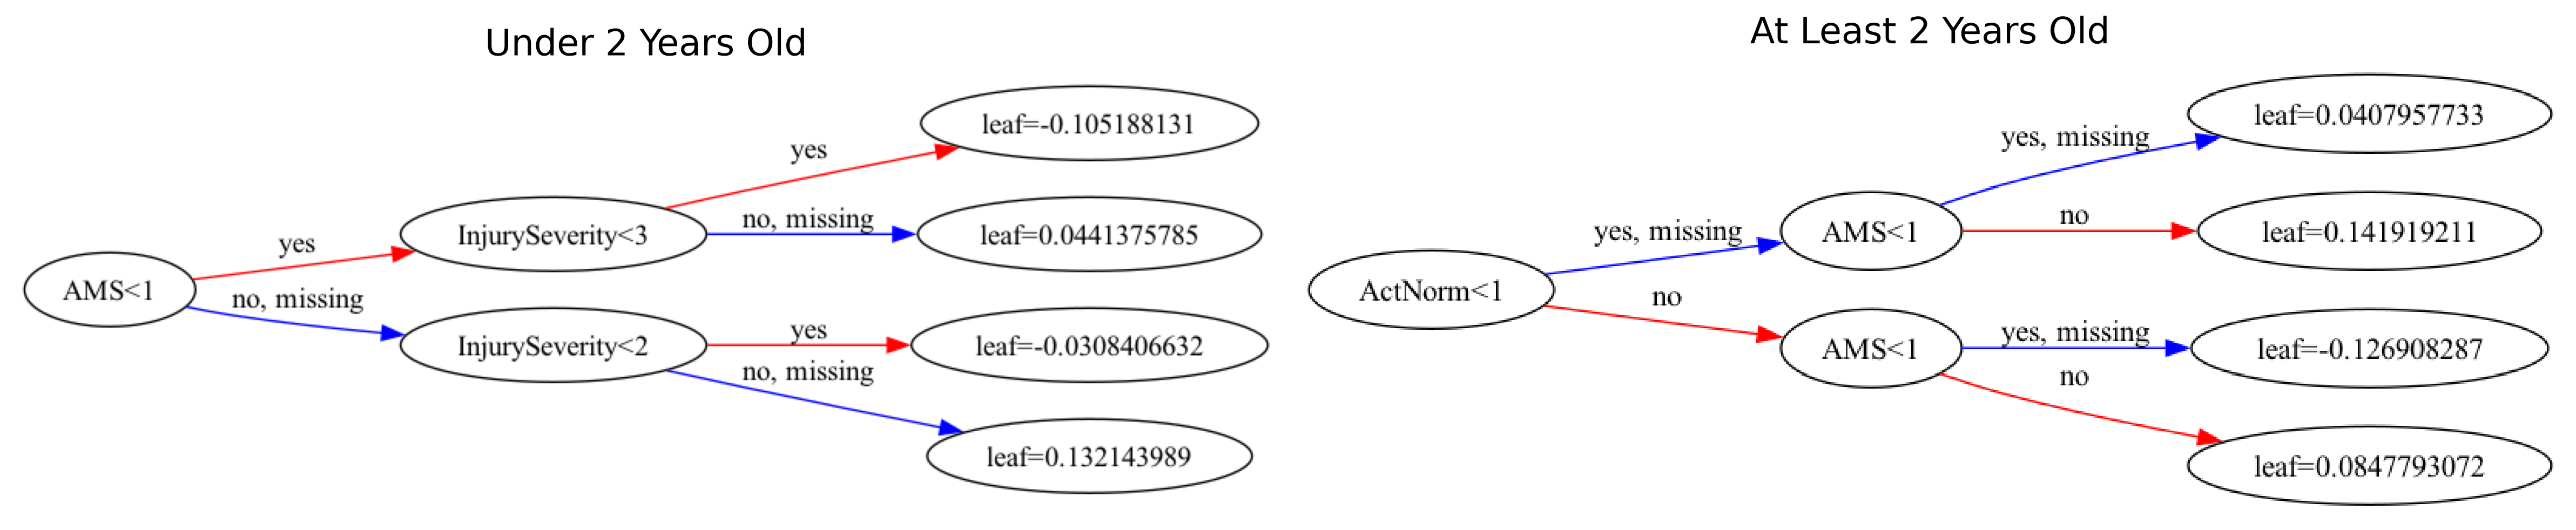

In [40]:
# Model 2: XGBoost Classifier for Age < 2 and Age >= 2 groups using cleaned data. To learn hyperparameters 'max_depth', 'learning_rate', and 'n_estimators', use CV to find optimal values.

X_train_processed_under_2 = train_data_under_2_cleaned.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()

X_train_processed_over_2 = train_data_over_2_cleaned.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()
    
for col in X_train_processed_under_2.select_dtypes(include=['object', 'string']).columns:
    cats = X_train_processed_under_2[col].astype('category')
    # Get category codes (which temporarily uses -1 for NaNs) and turn them back to true np.nan
    X_train_processed_under_2[col] = cats.cat.codes.astype(float).replace({-1.0: np.nan})

for col in X_train_processed_over_2.select_dtypes(include=['object', 'string']).columns:
    cats = X_train_processed_over_2[col].astype('category')
    # Get category codes (which temporarily uses -1 for NaNs) and turn them back to true np.nan
    X_train_processed_over_2[col] = cats.cat.codes.astype(float).replace({-1.0: np.nan})

y_train_binary_under_2 = train_data_under_2_cleaned['ciTBI'].map({'Yes': 1, 'No': 0})

y_train_binary_over_2 = train_data_over_2_cleaned['ciTBI'].map({'Yes': 1, 'No': 0})

grid_search_params = {
    'max_depth': [2, 3, 4, 5, 6],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200]
}

cv_under_2_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(objective='binary:logistic', random_state=42),
    param_grid=grid_search_params,
    scoring='roc_auc',
    cv=10,
    n_jobs=-1
)

cv_under_2_xgb.fit(X_train_processed_under_2, y_train_binary_under_2)

cv_over_2_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(objective='binary:logistic', random_state=42),
    param_grid=grid_search_params,
    scoring='roc_auc',
    cv=10,
    n_jobs=-1
)

cv_over_2_xgb.fit(X_train_processed_over_2, y_train_binary_over_2)

print(f"Optimal parameters for under 2 yrs: {cv_under_2_xgb.best_params_}")
print(f"Optimal parameters for at least 2 yrs: {cv_over_2_xgb.best_params_}")


xgb_under_2 = train_xg_boost(X_train=X_train_processed_under_2, y_train=y_train_binary_under_2, max_depth=cv_under_2_xgb.best_params_['max_depth'], learning_rate=cv_under_2_xgb.best_params_['learning_rate'], n_estimators=cv_under_2_xgb.best_params_['n_estimators'])
xgb_over_2 = train_xg_boost(X_train=X_train_processed_over_2, y_train=y_train_binary_over_2, max_depth=cv_over_2_xgb.best_params_['max_depth'], learning_rate=cv_over_2_xgb.best_params_['learning_rate'], n_estimators=cv_over_2_xgb.best_params_['n_estimators'])

plt.rcParams['figure.dpi'] = 300
plt.rcParams['text.usetex'] = False

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8))

# < 2
xgb.plot_tree(
    xgb_under_2, 
    tree_idx=0, 
    rankdir='LR',
    ax=axes[0]
)
axes[0].set_title(r"Under $2$ Years Old", fontsize=16, pad=10)

# >= 2
xgb.plot_tree(
    xgb_over_2, 
    tree_idx=0, 
    rankdir='LR',
    ax=axes[1]
)
axes[1].set_title(r"At Least $2$ Years Old", fontsize=16, pad=10)

plt.tight_layout()
plt.savefig(dir / 'figs' / 'xg_boost.png', dpi=300, bbox_inches='tight')
plt.show()

To accommodate binary, cateogrical, and clinical missing data without dropping rows or using arbitrary imputation, the custom training functions convert text categories into numeric codes whil preserving NaN values as true missingness (DecisionTreeClassifier automatically handles np.nans whereas we had to ensure np.nans are correctly converted after encoding for XGBoost). Both tree based models process the data input, and XGBoost leverages default direction routing to let missing clinical features dynamically minimize model loss. To tune both models and control complexity, you can adjust max_depth in both functions, which dictate thow deep the tree can grow (preventing overfitting), alongside n_estimators (the total number of sequential trees), and the learning rate (the step-size shrinkage for updates) in XGBoost. For both models, all hyperparameters (max_depth, learning_rate, and n_estimators was acquired using CV, 10 folds).

In [41]:
# Evaluate the models on the test data for both age groups.

cleaned_test_data_under_2 = clean(reduced_test_data_under_2)
cleaned_test_data_over_2 = clean(reduced_test_data_over_2)

X_test_under_2 = cleaned_test_data_under_2.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()

for col in X_test_under_2.columns:
    if X_test_under_2[col].dtype == 'object':
        if X_test_under_2[col].nunique() == 2:
                # Convert 'Yes'/'No' to 1/0
            X_test_under_2[col] = X_test_under_2[col].map({'Yes': 1, 'No': 0})
        elif X_test_under_2[col].nunique() > 2:
                # Convert categorical variables to ordinal
            X_test_under_2[col] = pd.Categorical(X_test_under_2[col]).codes

X_test_over_2 = cleaned_test_data_over_2.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()

for col in X_test_over_2.columns:
    if X_test_over_2[col].dtype == 'object':
        if X_test_over_2[col].nunique() == 2:
                # Convert 'Yes'/'No' to 1/0
            X_test_over_2[col] = X_test_over_2[col].map({'Yes': 1, 'No': 0})
        elif X_test_over_2[col].nunique() > 2:
                # Convert categorical variables to ordinal
            X_test_over_2[col] = pd.Categorical(X_test_over_2[col]).codes

dt_under_2_predictions = dec_tree_under_2.predict(X_test_under_2)
dt_over_2_predictions = dec_tree_over_2.predict(X_test_over_2)

X_test_processed_under_2 = cleaned_test_data_under_2.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()

for col in X_test_processed_under_2.select_dtypes(include=['object', 'string']).columns:
    cats = X_test_processed_under_2[col].astype('category')
    # Get category codes (which temporarily uses -1 for NaNs) and turn them back to true np.nan
    X_test_processed_under_2[col] = cats.cat.codes.astype(float).replace({-1.0: np.nan})

X_test_processed_over_2 = cleaned_test_data_over_2.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()

for col in X_test_processed_over_2.select_dtypes(include=['object', 'string']).columns:
    cats = X_test_processed_over_2[col].astype('category')
    # Get category codes (which temporarily uses -1 for NaNs) and turn them back to true np.nan
    X_test_processed_over_2[col] = cats.cat.codes.astype(float).replace({-1.0: np.nan})

xgb_under_2_predictions = xgb_under_2.predict(X_test_processed_under_2)
xgb_over_2_predictions = xgb_over_2.predict(X_test_processed_over_2)

y_true_under_2 = cleaned_test_data_under_2['ciTBI'].map({'Yes': 1, 'No': 0})
y_true_over_2 = cleaned_test_data_over_2['ciTBI'].map({'Yes': 1, 'No': 0})

sensitivity_dt_under_2, npv_dt_under_2 = compute_sensitivity_npv(y_true_under_2, dt_under_2_predictions)
sensitivity_dt_over_2, npv_dt_over_2 = compute_sensitivity_npv(y_true_over_2, dt_over_2_predictions)
sensitivity_xgb_under_2, npv_xgb_under_2 = compute_sensitivity_npv(y_true_under_2, xgb_under_2_predictions)
sensitivity_xgb_over_2, npv_xgb_over_2 = compute_sensitivity_npv(y_true_over_2, xgb_over_2_predictions)


print(f"Decision Tree - Under 2: Sensitivity: {sensitivity_dt_under_2:.5f}, NPV: {npv_dt_under_2:.5f}")
print(f"Decision Tree - Over 2: Sensitivity: {sensitivity_dt_over_2:.5f}, NPV: {npv_dt_over_2:.5f}")
print(f"XGBoost - Under 2: Sensitivity: {sensitivity_xgb_under_2:.5f}, NPV: {npv_xgb_under_2:.5f}")
print(f"XGBoost - Over 2: Sensitivity: {sensitivity_xgb_over_2:.5f}, NPV: {npv_xgb_over_2:.5f}")

Decision Tree - Under 2: Sensitivity: 0.80952, NPV: 0.99742
Decision Tree - Over 2: Sensitivity: 0.76923, NPV: 0.99682
XGBoost - Under 2: Sensitivity: 0.85714, NPV: 0.99838
XGBoost - Over 2: Sensitivity: 0.80000, NPV: 0.99756


Firstly, looking at the decision trees we see a few things. Firstly, it is off note that the decision trees were fiting using data from all predictors in Kuppermann et al. plus age. All 6 predictors of both age groups (with overlap) were passed into both models. Both decision trees were relatively shallow, with depth of two. While sensitivity was not as maximized as is in Kuppermann et al., we also notice that the number of predictors used is 2, instead of 6, indicating that we can actaully recover a decent (emphasis of decent) sensitivity rate for an even simpler CDR. While, in my person opinion, we should not replace the current CDR with these simpler rules, this modeling does give us much clinical insight into the data and the predictors that are most important for predicting ciTBI in both age groups.

For under 2 years old, the model only makes decisions off whether the child has altered mental status, then further breaks down the decision based on the child's injury severity. For example, if the child does not have an altered mental status, but has a high injury severity, we predict that the child might have ciTBI and thus needs a CT scan. Since having altered mental status provides evidence of ciTBI by itself, if the child has either a moderator or high injury severity, we would recommend CT. There is a relatively high (comparable to Kuppermann et al.) NPV, but we do lack sensitivity gained from make a more complex CDR. For this reason, it is not suggested to update the rule to be any simpler, as we want to maximize sensitivity -- if a child truly has a ciTBI, we should catch that.


For children at least 2 years old, the model only makes decisions on whether the child is acting normal, then further breaks down the decision based on the child's mental status. If the child is not acting normally, we recommend CT, and if the child is acting normally, if their have and altered mental status, we recommend CT. Again, due to the lack of sensitivity compared to the orginal CDR, we would not recommend switching to the similar model, but these simpler CDR do recover a decent amount of the sensitivity as well.

Secondly, looking at the XGBoost model, we see relatively similar behavior: the simpler CDR can obtain a decent sensitivity, but should not replace the more complex CDR as they capture more true ciTBI cases (the goal).

For under 2 years old, XGBoost considers the child's altered mental status and injury severity. If the child has a high severity injury, regards of the mental status, we recommend CT. If the child has an altered mental status, then we recommend CT if the injury severity is either moderate or high (which is also covered in the previous recommendation). Again, this simpler model (2 features instead of 6) does recover a decent sensitivty which is indicative that these variables are extremely informative for recommending CT scan, but should not replace the more complex CDR as we want to maximize sensitivity.

For at least 2 years old, the XGBoost considers whether the child is acting normal and their altered mental status. If the child is not acting normal, CT is recommended. IF they are acting normal, but they have an altered mental status, CT is recommended. Otherwise, CT is not recommended for the child. Same behavior as all other models here, these rules are simpler and not terrible performers but should not replace current standards and it does not maximize sensitivity.

Do note that each model was created in such a way to account for the rarenenss of ciTBI, this step was necessary to gain any sensitivity.

## Stability Check

Optimal max_depth for under 2 yrs: 2
Optimal max_depth for at least 2 yrs: 2


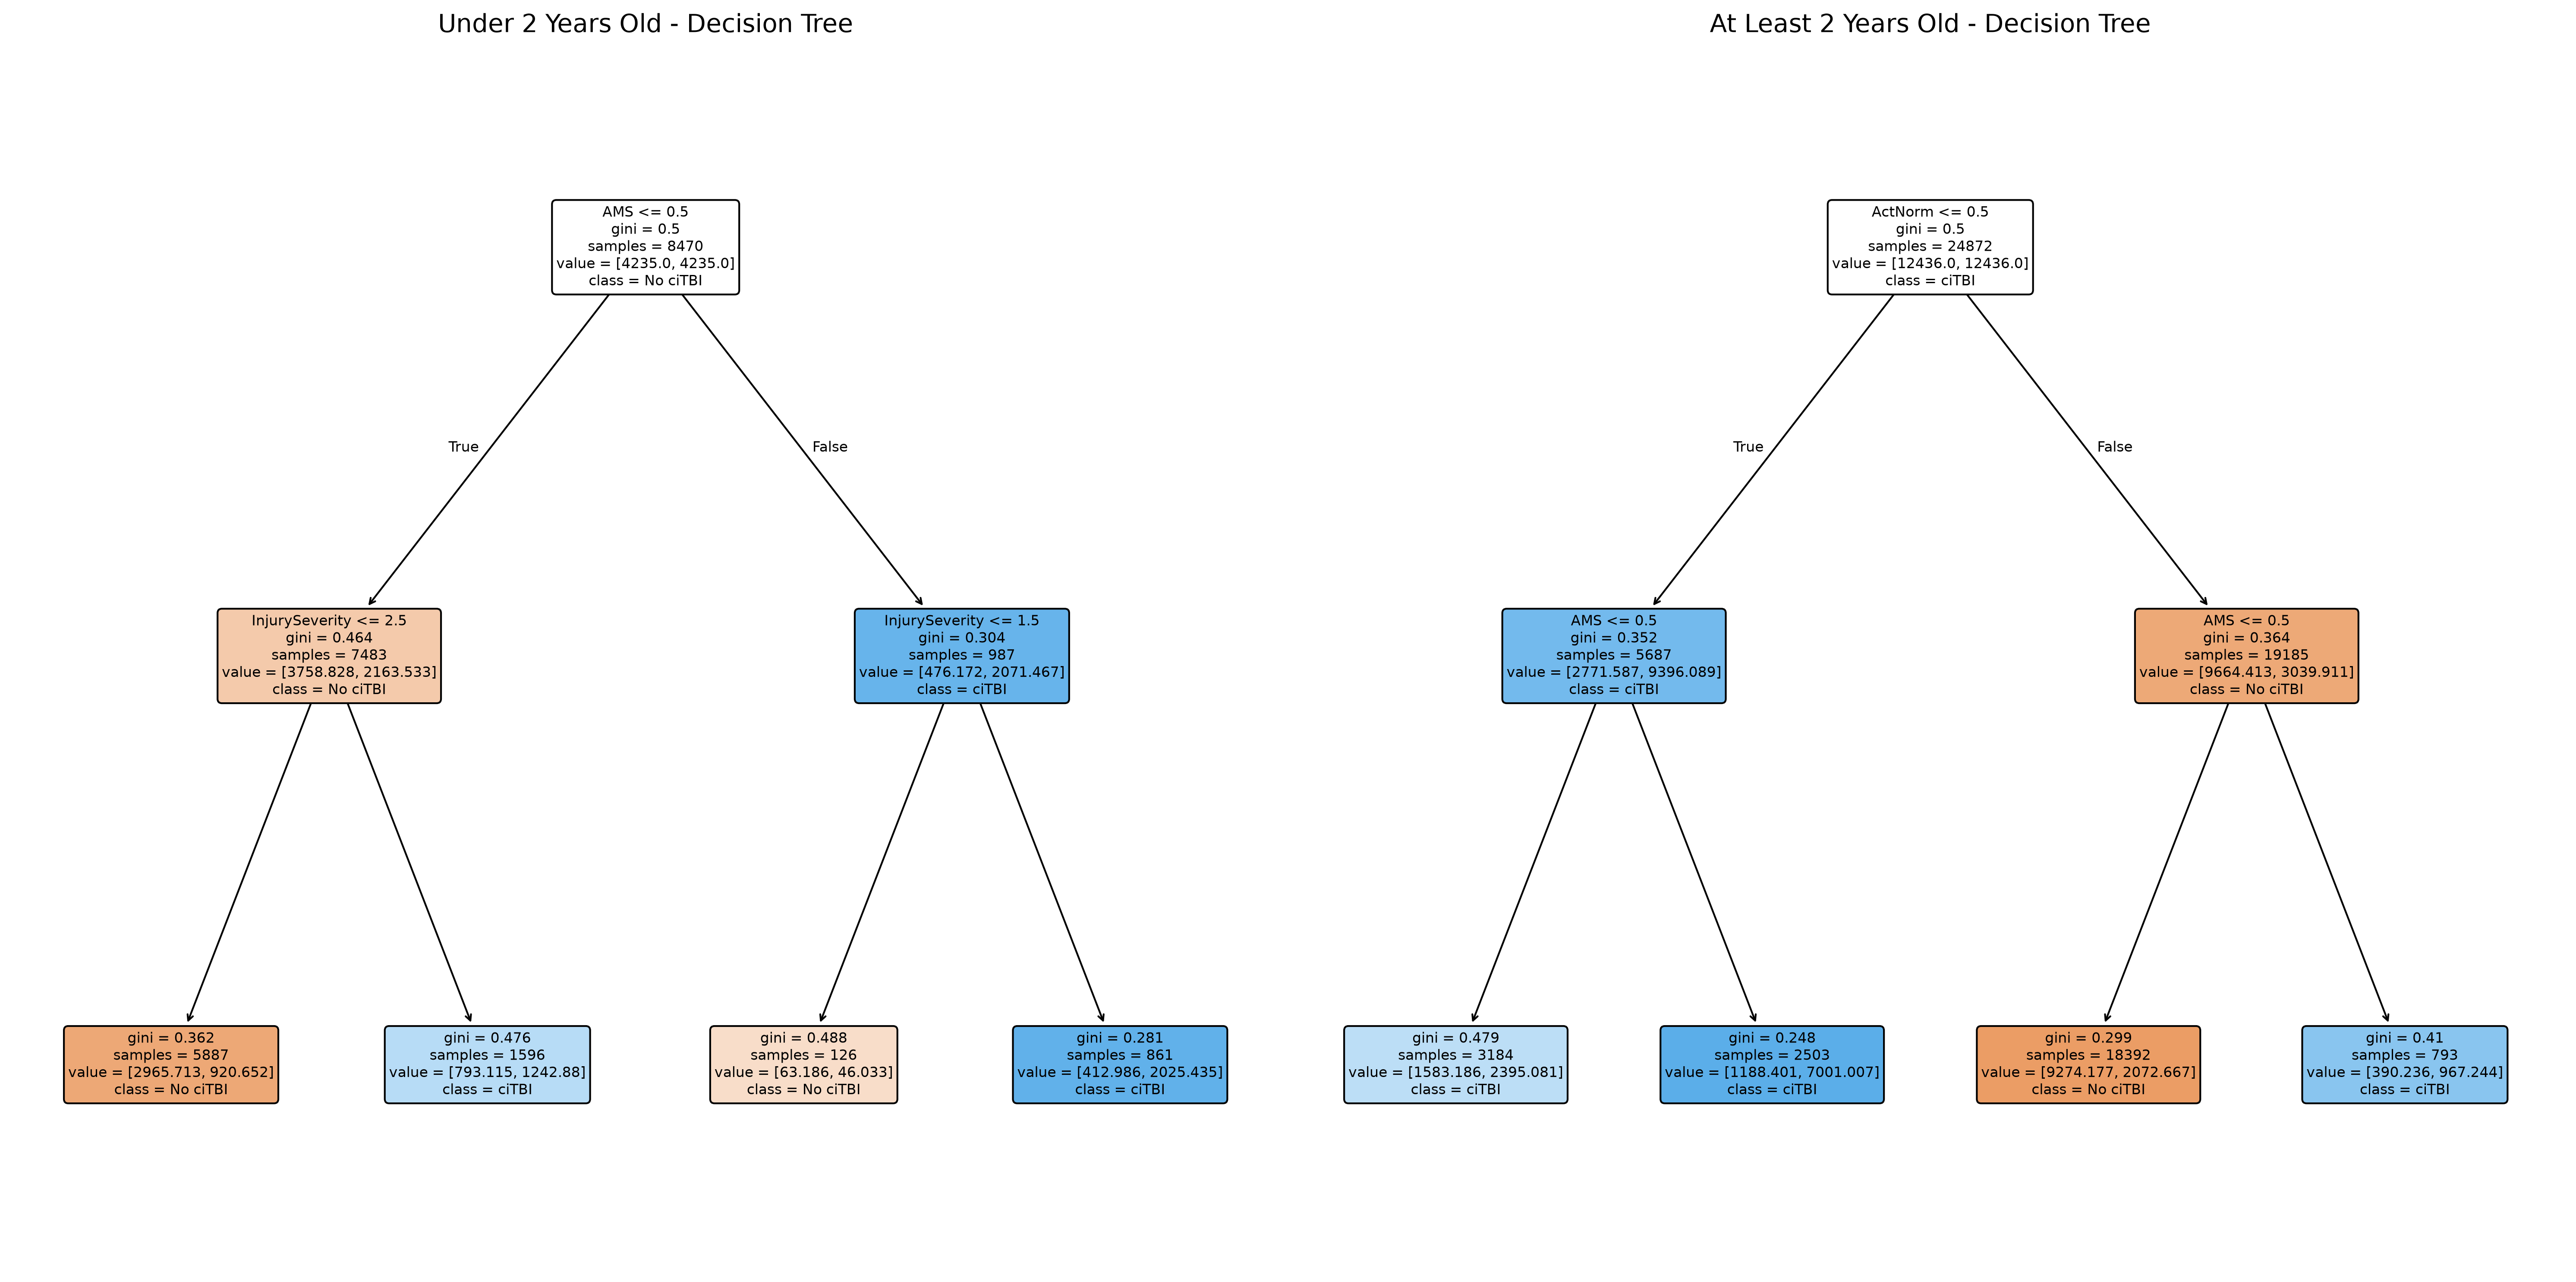

In [42]:
# Model 1: Decision Tree Classifier for Age < 2 and Age >= 2 groups using cleaned data. To learn hyperparameter 'max_depth', use CV to find optimal value

X_train_under_2 = cleaned_stab_check_under_2.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()
for col in X_train_under_2.columns:
    if X_train_under_2[col].dtype == 'object':
        if X_train_under_2[col].nunique() == 2:
            # Convert 'Yes'/'No' to 1/0
            X_train_under_2[col] = X_train_under_2[col].map({'Yes': 1, 'No': 0})
        elif X_train_under_2[col].nunique() > 2:
                    # Convert categorical variables to ordinal
                    X_train_under_2[col] = pd.Categorical(X_train_under_2[col]).codes

X_train_over_2 = cleaned_stab_check_over_2.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()
for col in X_train_over_2.columns:
    if X_train_over_2[col].dtype == 'object':
        if X_train_over_2[col].nunique() == 2:
            # Convert 'Yes'/'No' to 1/0
            X_train_over_2[col] = X_train_over_2[col].map({'Yes': 1, 'No': 0})
        elif X_train_over_2[col].nunique() > 2:
            # Convert categorical variables to ordinal
            X_train_over_2[col] = pd.Categorical(X_train_over_2[col]).codes

    y_train_binary_under = cleaned_stab_check_under_2['ciTBI'].map({'Yes': 1, 'No': 0})
    y_train_binary_over = cleaned_stab_check_over_2['ciTBI'].map({'Yes': 1, 'No': 0})

param_grid = {'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10]}

cv_under_2 = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=10)
cv_under_2.fit(X_train_under_2, y_train_binary_under)

cv_over_2 = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=10)
cv_over_2.fit(X_train_over_2, y_train_binary_over)

print(f"Optimal max_depth for under 2 yrs: {cv_under_2.best_params_['max_depth']}")
print(f"Optimal max_depth for at least 2 yrs: {cv_over_2.best_params_['max_depth']}")

under_2_best_depth = cv_under_2.best_params_['max_depth']
over_2_best_depth = cv_over_2.best_params_['max_depth']

dec_tree_under_2 = train_decision_tree(X_train=X_train_under_2, y_train=y_train_binary_under, max_depth = under_2_best_depth)
dec_tree_over_2 = train_decision_tree(X_train=X_train_over_2, y_train=y_train_binary_over, max_depth = over_2_best_depth)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

skl.tree.plot_tree(
    dec_tree_under_2,
    ax=axes[0],
    feature_names=X_train_under_2.columns,
    class_names=['No ciTBI', 'ciTBI'],
    filled=True,
    rounded=True
)
axes[0].set_title("Under 2 Years Old - Decision Tree", fontsize=14)

skl.tree.plot_tree(
    dec_tree_over_2,
    ax=axes[1],
    feature_names=X_train_over_2.columns,
    class_names=['No ciTBI', 'ciTBI'],
    filled=True,
    rounded=True
)
axes[1].set_title("At Least 2 Years Old - Decision Tree", fontsize=14)

plt.tight_layout()
plt.savefig(dir / 'figs' / 'decsion_tree_perturbed.png', dpi=300, bbox_inches='tight')
plt.show()


Optimal parameters for under 2 yrs: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}
Optimal parameters for at least 2 yrs: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}


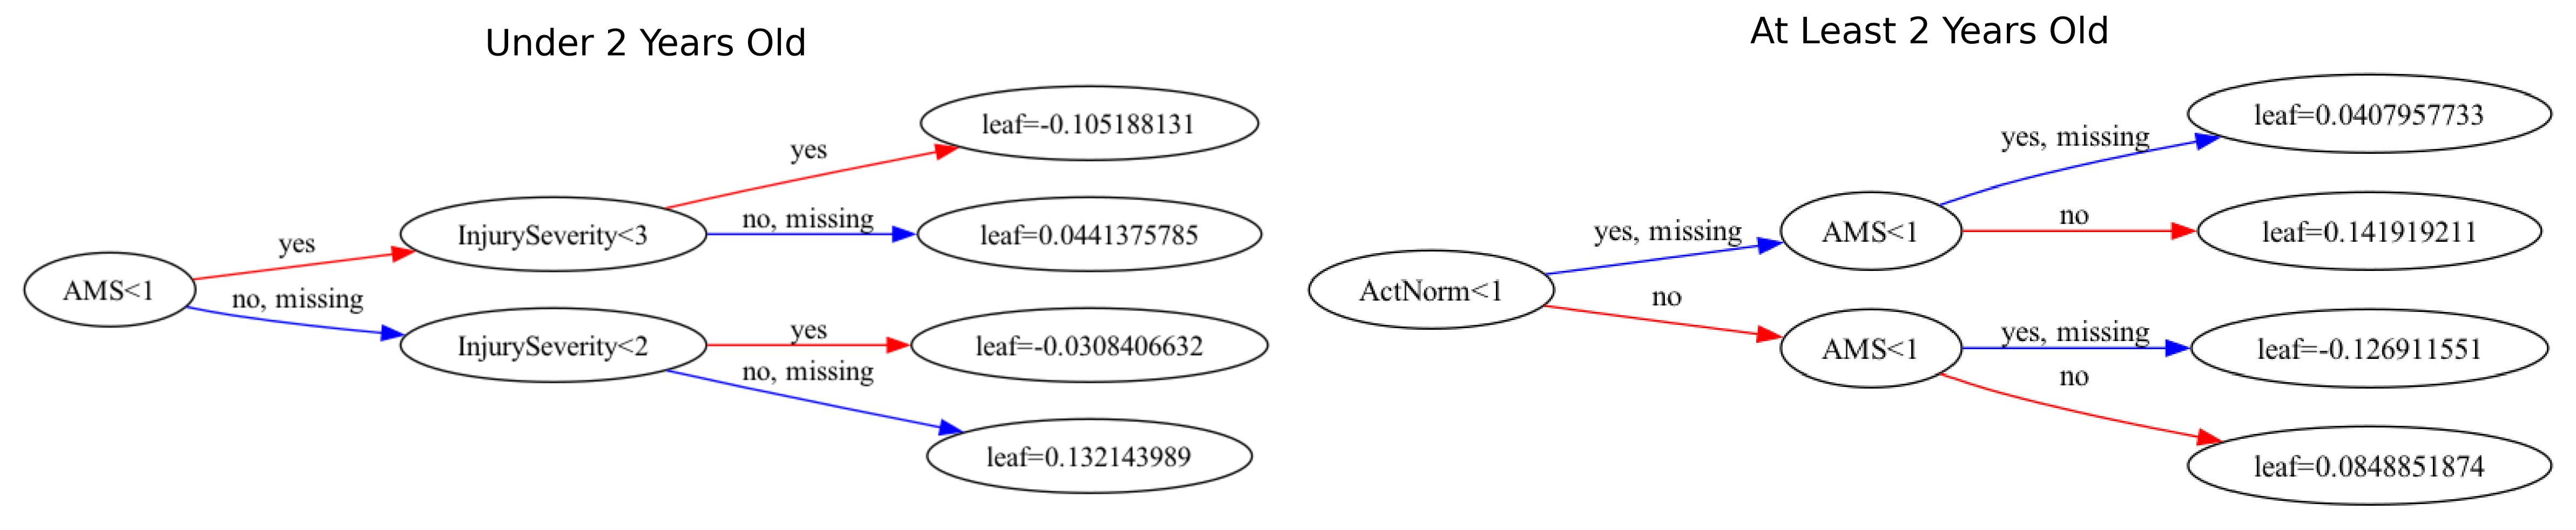

In [43]:
# Model 2: XGBoost Classifier for Age < 2 and Age >= 2 groups using cleaned data. To learn hyperparameters 'max_depth', 'learning_rate', and 'n_estimators', use CV to find optimal values.

X_train_processed_under_2 = cleaned_stab_check_under_2.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()

X_train_processed_over_2 = cleaned_stab_check_over_2.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()
    
for col in X_train_processed_under_2.select_dtypes(include=['object', 'string']).columns:
    cats = X_train_processed_under_2[col].astype('category')
    # Get category codes (which temporarily uses -1 for NaNs) and turn them back to true np.nan
    X_train_processed_under_2[col] = cats.cat.codes.astype(float).replace({-1.0: np.nan})

for col in X_train_processed_over_2.select_dtypes(include=['object', 'string']).columns:
    cats = X_train_processed_over_2[col].astype('category')
    # Get category codes (which temporarily uses -1 for NaNs) and turn them back to true np.nan
    X_train_processed_over_2[col] = cats.cat.codes.astype(float).replace({-1.0: np.nan})

y_train_binary_under_2 = cleaned_stab_check_under_2['ciTBI'].map({'Yes': 1, 'No': 0})

y_train_binary_over_2 = cleaned_stab_check_over_2['ciTBI'].map({'Yes': 1, 'No': 0})

grid_search_params = {
    'max_depth': [2, 3, 4, 5, 6],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200]
}

cv_under_2_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(objective='binary:logistic', random_state=42),
    param_grid=grid_search_params,
    scoring='roc_auc',
    cv=10,
    n_jobs=-1
)

cv_under_2_xgb.fit(X_train_processed_under_2, y_train_binary_under_2)

cv_over_2_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(objective='binary:logistic', random_state=42),
    param_grid=grid_search_params,
    scoring='roc_auc',
    cv=10,
    n_jobs=-1
)

cv_over_2_xgb.fit(X_train_processed_over_2, y_train_binary_over_2)

print(f"Optimal parameters for under 2 yrs: {cv_under_2_xgb.best_params_}")
print(f"Optimal parameters for at least 2 yrs: {cv_over_2_xgb.best_params_}")


xgb_under_2 = train_xg_boost(X_train=X_train_processed_under_2, y_train=y_train_binary_under_2, max_depth=cv_under_2_xgb.best_params_['max_depth'], learning_rate=cv_under_2_xgb.best_params_['learning_rate'], n_estimators=cv_under_2_xgb.best_params_['n_estimators'])
xgb_over_2 = train_xg_boost(X_train=X_train_processed_over_2, y_train=y_train_binary_over_2, max_depth=cv_over_2_xgb.best_params_['max_depth'], learning_rate=cv_over_2_xgb.best_params_['learning_rate'], n_estimators=cv_over_2_xgb.best_params_['n_estimators'])

plt.rcParams['figure.dpi'] = 300
plt.rcParams['text.usetex'] = False

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8))

# < 2
xgb.plot_tree(
    xgb_under_2, 
    tree_idx=0, 
    rankdir='LR',
    ax=axes[0]
)
axes[0].set_title(r"Under $2$ Years Old", fontsize=16, pad=10)

# >= 2
xgb.plot_tree(
    xgb_over_2, 
    tree_idx=0, 
    rankdir='LR',
    ax=axes[1]
)
axes[1].set_title(r"At Least $2$ Years Old", fontsize=16, pad=10)

plt.tight_layout()
plt.savefig(dir / 'figs' / 'xg_boost_perturbed.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
# Evaluate the models on the test data for both age groups.

cleaned_stab_test_data_under_2 = clean(reduced_test_data_under_2, gcs_total = False, suspected = False, new_severity = False)
cleaned_stab_test_data_over_2 = clean(reduced_test_data_over_2, gcs_total = False, suspected = False, new_severity = False)

X_test_under_2 = cleaned_stab_test_data_under_2.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()

for col in X_test_under_2.columns:
    if X_test_under_2[col].dtype == 'object':
        if X_test_under_2[col].nunique() == 2:
                # Convert 'Yes'/'No' to 1/0
            X_test_under_2[col] = X_test_under_2[col].map({'Yes': 1, 'No': 0})
        elif X_test_under_2[col].nunique() > 2:
                # Convert categorical variables to ordinal
            X_test_under_2[col] = pd.Categorical(X_test_under_2[col]).codes

X_test_over_2 = cleaned_stab_test_data_over_2.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()

for col in X_test_over_2.columns:
    if X_test_over_2[col].dtype == 'object':
        if X_test_over_2[col].nunique() == 2:
                # Convert 'Yes'/'No' to 1/0
            X_test_over_2[col] = X_test_over_2[col].map({'Yes': 1, 'No': 0})
        elif X_test_over_2[col].nunique() > 2:
                # Convert categorical variables to ordinal
            X_test_over_2[col] = pd.Categorical(X_test_over_2[col]).codes

dt_under_2_predictions = dec_tree_under_2.predict(X_test_under_2)
dt_over_2_predictions = dec_tree_over_2.predict(X_test_over_2)

X_test_processed_under_2 = cleaned_stab_test_data_under_2.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()

for col in X_test_processed_under_2.select_dtypes(include=['object', 'string']).columns:
    cats = X_test_processed_under_2[col].astype('category')
    # Get category codes (which temporarily uses -1 for NaNs) and turn them back to true np.nan
    X_test_processed_under_2[col] = cats.cat.codes.astype(float).replace({-1.0: np.nan})

X_test_processed_over_2 = cleaned_stab_test_data_over_2.drop(['ciTBI', 'InjuryMech', 'Race', 'CTDone'], axis=1).copy()

for col in X_test_processed_over_2.select_dtypes(include=['object', 'string']).columns:
    cats = X_test_processed_over_2[col].astype('category')
    # Get category codes (which temporarily uses -1 for NaNs) and turn them back to true np.nan
    X_test_processed_over_2[col] = cats.cat.codes.astype(float).replace({-1.0: np.nan})

xgb_under_2_predictions = xgb_under_2.predict(X_test_processed_under_2)
xgb_over_2_predictions = xgb_over_2.predict(X_test_processed_over_2)

y_true_under_2 = cleaned_test_data_under_2['ciTBI'].map({'Yes': 1, 'No': 0})
y_true_over_2 = cleaned_test_data_over_2['ciTBI'].map({'Yes': 1, 'No': 0})

sensitivity_dt_under_2, npv_dt_under_2 = compute_sensitivity_npv(y_true_under_2, dt_under_2_predictions)
sensitivity_dt_over_2, npv_dt_over_2 = compute_sensitivity_npv(y_true_over_2, dt_over_2_predictions)
sensitivity_xgb_under_2, npv_xgb_under_2 = compute_sensitivity_npv(y_true_under_2, xgb_under_2_predictions)
sensitivity_xgb_over_2, npv_xgb_over_2 = compute_sensitivity_npv(y_true_over_2, xgb_over_2_predictions)


print(f"Decision Tree - Under 2: Sensitivity: {sensitivity_dt_under_2:.5f}, NPV: {npv_dt_under_2:.5f}")
print(f"Decision Tree - Over 2: Sensitivity: {sensitivity_dt_over_2:.5f}, NPV: {npv_dt_over_2:.5f}")
print(f"XGBoost - Under 2: Sensitivity: {sensitivity_xgb_under_2:.5f}, NPV: {npv_xgb_under_2:.5f}")
print(f"XGBoost - Over 2: Sensitivity: {sensitivity_xgb_over_2:.5f}, NPV: {npv_xgb_over_2:.5f}")

Decision Tree - Under 2: Sensitivity: 0.80952, NPV: 0.99742
Decision Tree - Over 2: Sensitivity: 0.76923, NPV: 0.99682
XGBoost - Under 2: Sensitivity: 0.85714, NPV: 0.99837
XGBoost - Over 2: Sensitivity: 0.80000, NPV: 0.99756


Upon perturbing the data, we see that the model is identical: the variables used, interpretation, and performance metrics remain the same. This suggests that the model is robust to small changes in the data, which is a positive indication of its reliability. Even when variables like AMS, LOC, and severity were perturbed, our decision splits remain identical, indicating that the data cleaning choices made do not change the underlying data structure, and these simpler CDR are consistent. Again, we would not recommend replacement as sensitivity is not maximized, but these models are informative.

## Conclusion

One key attribute of the data was how rare ciTBI was with respect to the set of child considered in this analysis. This rarity of ciTBI cases is reflected in the simpler CDRs lack of sensitivity. We do get quite a bit of power due to the large number of children considered in this analysis, but the rarity of ciTBI cases is a challenge for any model. The XGBoost model does a better job of capturing the rare ciTBI cases than the decision tree model, but the sensitivity is still not as high as we would like. The NPV is quite high for both models, which is good, but the sensitivity is the more important metric for this analysis. One challenged faced was simply: where does one start with such a messy, large dataset? Many decisions were made to exclude variables based off of their information of CT (which we are trying to make recommendations on) and repetitive information (i.e. subcategories of the same variable). Another limitation revolved around the fact missingness is meaningful in settings like this: was the variable missing because the patient was unconscious? If so, that is a meaninful missing value in terms of potentially having a ciTBI. For this reason, no mode imputation was done as that make too many assumptions about the individual cases of injury and symptoms towards making conclusions about ciTBI. Due to no imputing NaNs, model choice was restricted to models that can handle NaNs. I tangentially think that these models were relatively appropriate as they are easy to interpret and directly comparable to how the orginal, gold-standard CDR were established. The data cleaning step was most centered around trying to root the data in a real, clinical setting. Another limitation of the data was the lack of data for proper data splitting. Kuppermann specifically mentions that data was collected after the initial collection to mimic future data, but data were not time stamped to allow for proper data splitting. Additionally, these data are from 25 different hospitals, but patients were not recorded as to which hospital they were from, also limiting the data splitting and verifiability of inter-hospital variability. 

The paper also mentions that 4% of patients at each hospital had two evaluations to check for inter-rater variability, but this data was no made available and thus the claim must simply be accepted, as it cannot be checked.


This lab is not a one-to-one correspondence of the data and reality. As it was explored throughout the lab, there was many problems, many of which someone with lack of subject matter experise, as myself, cannot justifiable fix to reflect reality better. The analyses hoped to capture a meaningful, interpretable rule for CT recommendation but there was so much arbitrary cleaning and data manipulation that the results are not generalizable to the real world. The data visualization on the other hand did show some relationships that we know to be true about the real world, so the data is at least semi-grounded in reality.